# Relation Extraction

**Пилотная выборка:**

- `50` документов DocRED — обычная случайная выборка;
- по `50` примеров для `QA`, `Summary` и `Data2txt` из RAGTruth;
- `50` системных резюме XSum;
- для каждой задачи обнаружения галлюцинаций: `25` обычных и `25` галлюцинированных примеров;
- `random_seed = 42`.

**Сравниваемые системы:**

1. Qwen2.5-7B-Instruct извлекает только отношения для сущностей spaCy;
2. GLiREL с сущностями spaCy;
3. GLiREL с gold-сущностями DocRED;
4. GLiNER-Relex — end-to-end NER + RE;
5. REBEL — end-to-end генеративное извлечение триплетов.

Для DocRED выполняются два независимых прогона: с исходными 96 отношениями DocRED и с компактной схемой отношений. Для RAGTruth и XSum наша схема применяется там, где модель поддерживает заданную схему; REBEL сохраняет собственные названия отношений, чтобы не менять его естественный режим работы.

## 1. Установка зависимостей

In [ ]:
# Совместимый стек для Google Colab / Python 3.12.
# PyTorch не переустанавливаем: Colab подбирает его под доступную CUDA.
%pip install -q --upgrade --upgrade-strategy only-if-needed \
    "transformers==4.51.3" \
    "tokenizers==0.21.1" \
    "huggingface-hub==0.30.2" \
    "accelerate==1.6.0" \
    "bitsandbytes==0.45.5" \
    "glirel==1.2.1" \
    "gliner==0.2.26" \
    "sentencepiece==0.2.0" \
    "protobuf==5.29.4" \
    "loguru==0.7.3" \
    "spacy==3.8.5" \
    "datasets==3.5.0" \
    "networkx==3.4.2" \
    "tqdm==4.67.1"

!python -m spacy download en_core_web_sm -q
!python -m pip check

from importlib.metadata import version

_COMPAT_PACKAGES = [
    "transformers", "tokenizers", "huggingface-hub", "accelerate",
    "bitsandbytes", "glirel", "gliner", "sentencepiece",
    "protobuf", "loguru", "spacy", "datasets", "networkx", "tqdm",
]
print("Установленные версии:")
for package_name in _COMPAT_PACKAGES:
    print(f"  {package_name}: {version(package_name)}")


## 2. Импорты, воспроизводимость и конфигурация

Пороговые значения моделей вынесены в один блок. В пилоте они фиксированы до запуска на тестовых 50 примерах; веса итогового детектора оцениваются только по out-of-fold предсказаниям.

In [ ]:
import gc
import hashlib
import json
import math
import os
import random
import re
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Iterable, Optional

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import spacy
import torch
from scipy.optimize import minimize
from sklearn.metrics import (
    accuracy_score,
    auc,
    f1_score,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Устройство:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Устройство: cuda
GPU: NVIDIA TITAN RTX
VRAM: 25.4 GB


/mnt/hdd2/29i_kos/env/notebook/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ── пути ────────────────────────────────────────────────────
ROOT = Path("/content") if Path("/content").exists() else Path.cwd()
DATA_DIR = ROOT / "data"
ASSET_DIR = ROOT
OUT_DIR = ROOT / "results"
CACHE_DIR = OUT_DIR / "cache"
PLOT_DIR = OUT_DIR / "plots"
for p in (DATA_DIR, OUT_DIR, CACHE_DIR, PLOT_DIR):
    p.mkdir(parents=True, exist_ok=True)

ONTOLOGY_PATH = ASSET_DIR / "hgr30_ontology_v1.json"
DOCRED_MAPPING_PATH = ASSET_DIR / "docred_to_hgr30_mapping_v1.json"

DOCRED_DEV_PATH = DATA_DIR / "dev.json"
DOCRED_REL_INFO_PATH = DATA_DIR / "rel_info.json"
RAGTRUTH_RESPONSE_PATH = DATA_DIR / "response.jsonl"
RAGTRUTH_SOURCE_PATH = DATA_DIR / "source_info.jsonl"
XSUM_ANNOTATIONS_PATH = DATA_DIR / "hallucination_annotations_xsum_summaries.csv"
XSUM_SCORES_PATH = DATA_DIR / "eval_scores_xsum_summaries.csv"

# ── размер пилота ───────────────────────────────────────────
N_DOCRED = 50
N_PER_TARGET_TASK = 50
N_HALLUCINATED = 25
N_CLEAN = 25

# ── модели ──────────────────────────────────────────────────
SPACY_MODEL = "en_core_web_sm"
LLM_MODEL = "unsloth/Qwen2.5-7B-Instruct-bnb-4bit"
GLIREL_MODEL = "jackboyla/glirel-large-v0"
GLINER_RELEX_MODEL = "knowledgator/gliner-relex-large-v1.0"
REBEL_MODEL = "Babelscape/rebel-large"

# Повторный запуск использует сохранённые JSONL вместо нового инференса.
REUSE_CACHE = True
RUN_MODELS = {
    "llm_spacy": True,
    "glirel_spacy": True,
    "glirel_gold": True,
    "gliner_relex": True,
    "rebel": True,
}

# ── режим обработки документов ─────────────────────────────
# True: исходная обработка несколькими перекрывающимися окнами.
# False: быстрый пилотный режим — ровно один проход на документ.
# Если полный текст не помещается в контекст модели, берётся один
# максимально длинный префикс; оставшаяся часть документа не обрабатывается.
USE_WINDOWING = False
SINGLE_PASS_TRUNCATE_TO_CONTEXT = True
PROCESSING_TAG = "windowed" if USE_WINDOWING else "single_pass"

# ── пороги и ограничения ───────────────────────────────────
LLM_CONTEXT_LIMIT = 32768
LLM_OUTPUT_RESERVE = 128
LLM_SCHEMA_BATCH_SIZE = 32

GLIREL_THRESHOLD = 0.30
GLIREL_CONTEXT_LIMIT = 512
GLIREL_SCHEMA_BATCH_SIZE = 32

GLINER_ENTITY_THRESHOLD = 0.35
GLINER_ADJACENCY_THRESHOLD = 0.55
GLINER_RELATION_THRESHOLD = 0.70
GLINER_CONTEXT_LIMIT = 512
GLINER_SCHEMA_BATCH_SIZE = 30

REBEL_CONTEXT_LIMIT = 512
REBEL_MAX_NEW_TOKENS = 256

WINDOW_OVERLAP_RATIO = 0.20
WINDOW_MIN_OVERLAP_SENTENCES = 1
WINDOW_SAFETY_TOKENS = 32

print("Корень проекта:", ROOT)
print("Каталог данных:", DATA_DIR)
print("Каталог результатов:", OUT_DIR)

Корень проекта: /mnt/hdd2/29i_kos/notebook
Каталог данных: /mnt/hdd2/29i_kos/notebook/data
Каталог результатов: /mnt/hdd2/29i_kos/notebook/results


## 3. Источники и выбранные модели

- **DocRED:** [ACL 2019](https://aclanthology.org/P19-1074/), [официальный репозиторий](https://github.com/thunlp/DocRED)
- **RAGTruth:** [ACL 2024](https://aclanthology.org/2024.acl-long.585/), [официальный репозиторий](https://github.com/ParticleMedia/RAGTruth)
- **XSum faithfulness annotations:** [ACL 2020](https://aclanthology.org/2020.acl-main.173/), [официальный набор аннотаций](https://github.com/google-research-datasets/xsum_hallucination_annotations)
- **GLiREL:** [NAACL 2025](https://aclanthology.org/2025.naacl-long.418/), [код](https://github.com/jackboyla/GLiREL), [модель](https://huggingface.co/jackboyla/glirel-large-v0)
- **GLiNER-Relex:** [arXiv:2605.10108](https://arxiv.org/abs/2605.10108), [модель](https://huggingface.co/knowledgator/gliner-relex-large-v1.0)
- **REBEL:** [Findings of EMNLP 2021](https://aclanthology.org/2021.findings-emnlp.204/), [модель](https://huggingface.co/Babelscape/rebel-large)

## 4. Загрузка HGR-30 и отображения DocRED → HGR-30

Файл отображения создаётся один раз и затем версионируется. Отношение DocRED отображается только тогда, когда оно логически влечёт отношение HGR-30 после возможной смены направления; тематически похожие, но неэквивалентные отношения остаются `out_of_scope`.

In [ ]:
def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

for required in (ONTOLOGY_PATH, DOCRED_MAPPING_PATH):
    assert required.exists(), f"Не найден файл: {required}. Загрузите его рядом с ноутбуком."

ontology = json.loads(ONTOLOGY_PATH.read_text(encoding="utf-8"))
docred_mapping = json.loads(DOCRED_MAPPING_PATH.read_text(encoding="utf-8"))

HGR_RELATIONS = ontology["relations"]
HGR_BY_ID = {r["id"]: r for r in HGR_RELATIONS}
HGR_LABEL_TO_ID = {r["model_label_en"]: r["id"] for r in HGR_RELATIONS}
HGR_ENTITY_LABELS = {
    e["model_label_en"]: e["description_en"] for e in ontology["entity_types"]
}
HGR_ENTITY_LABELS["other"] = "Any relation-bearing entity not covered by the listed broad types."

DOCRED_MAP_BY_ID = {x["docred_id"]: x for x in docred_mapping["relations"]}
DOCRED_LABEL_TO_ID = {x["docred_label"]: x["docred_id"] for x in docred_mapping["relations"]}

print(f"HGR-30: {len(HGR_RELATIONS)} отношений")
print("DocRED mapping:", docred_mapping["statistics"])
print("SHA256 ontology:", sha256_file(ONTOLOGY_PATH)[:16], "…")
print("SHA256 mapping: ", sha256_file(DOCRED_MAPPING_PATH)[:16], "…")

HGR-30: 30 отношений
DocRED mapping: {'docred_relation_types': 96, 'mapped_relation_types': 72, 'exact_relation_types': 35, 'entailed_broader_relation_types': 37, 'out_of_scope_relation_types': 24}
SHA256 ontology: 80a8a2ff5672b2a2 …
SHA256 mapping:  64c49256989e8c4e …


In [ ]:
# Компактное представление схемы для проверки командой.
ontology_table = pd.DataFrame([
    {
        "id": r["id"],
        "label": r["model_label_en"],
        "направленное": r["directed"],
        "описание": r["description_ru"],
    }
    for r in HGR_RELATIONS
])
display(ontology_table)

,id,label,направленное,описание
0,part_of,part of,True,"Компонент, подразделение, дочерняя организация..."
1,located_in,located in,True,Объект или событие физически либо администрати...
2,capital_of,capital of,True,Город или административный центр является стол...
3,born_in,born in,True,Человек родился в указанном месте.
4,died_in,died in,True,Человек умер в указанном месте.
5,citizen_of,citizen of,True,Человек имеет указанное гражданство или национ...
6,date_of_birth,date of birth,True,У человека указана дата рождения.
7,date_of_death,date of death,True,У человека указана дата смерти.
8,started_on,started on,True,"Организация, событие, процесс, правовой акт, п..."
9,ended_on,ended on,True,"Организация, событие, процесс, объект, правово..."


## 5. Загрузка датасетов и фиксированных пилотных выборок

Ожидаемая структура `/content/data/`:

```text
/content/data/
├── dev.json
├── rel_info.json
├── response.jsonl
├── source_info.jsonl
├── hallucination_annotations_xsum_summaries.csv
└── eval_scores_xsum_summaries.csv
```

Для XSum используется официальный агрегированный показатель `Faithful`. Строка из span-аннотаций нужна только для текста системного резюме; брать первую строку аннотации как итоговую метку нельзя.

In [ ]:
def load_jsonl(path: Path) -> list[dict]:
    records = []
    with path.open(encoding="utf-8", errors="replace") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as exc:
                raise ValueError(f"Некорректный JSONL: {path}, строка {line_no}") from exc
    return records


def balanced_group_sample(
    df: pd.DataFrame,
    label_col: str,
    group_col: str,
    n_pos: int = 25,
    n_neg: int = 25,
    random_state: int = 42,
) -> pd.DataFrame:
    """Выбирает по одному примеру на группу, сохраняя точный баланс классов."""
    rng = np.random.default_rng(random_state)
    selected = []
    for label, n in [(1, n_pos), (0, n_neg)]:
        part = df[df[label_col] == label].copy()
        groups = part[group_col].astype(str).unique().tolist()
        rng.shuffle(groups)
        for group in groups:
            candidates = part[part[group_col].astype(str) == group]
            idx = rng.choice(candidates.index.to_numpy())
            selected.append(idx)
            if sum(df.loc[i, label_col] == label for i in selected) >= n:
                break
        got = sum(df.loc[i, label_col] == label for i in selected)
        if got < n:
            raise ValueError(
                f"Недостаточно уникальных групп для класса {label}: нужно {n}, найдено {got}."
            )
    return df.loc[selected].sample(frac=1, random_state=random_state).reset_index(drop=True)


def ragtruth_is_hallucinated(labels: list[dict]) -> int:
    """implicit_true не формирует положительную метку в этом эксперименте."""
    for item in labels or []:
        if not bool(item.get("implicit_true", False)):
            return 1
    return 0


def serialize_source_info(task_type: str, source_info: Any) -> tuple[str, str]:
    """Возвращает (контекст, запрос) без дублирования контекста из prompt."""
    if task_type == "QA":
        return str(source_info.get("passages", "")), str(source_info.get("question", ""))
    if task_type == "Summary":
        return str(source_info), ""
    if task_type == "Data2txt":
        # Специальный JSON-граф намеренно не применяется в этом пилоте.
        return json.dumps(source_info, ensure_ascii=False, indent=2), ""
    raise ValueError(f"Неизвестный task_type: {task_type}")

In [ ]:
# ── DocRED ──────────────────────────────────────────────────
assert DOCRED_DEV_PATH.exists(), f"Не найден {DOCRED_DEV_PATH}"
docred_all = json.loads(DOCRED_DEV_PATH.read_text(encoding="utf-8"))

if DOCRED_REL_INFO_PATH.exists():
    docred_rel_info = json.loads(DOCRED_REL_INFO_PATH.read_text(encoding="utf-8"))
    expected = {x["docred_id"]: x["docred_label"] for x in docred_mapping["relations"]}
    assert docred_rel_info == expected, "rel_info.json не совпадает с версией, использованной в mapping JSON."
else:
    docred_rel_info = {x["docred_id"]: x["docred_label"] for x in docred_mapping["relations"]}

rng = np.random.default_rng(RANDOM_SEED)
docred_indices = rng.choice(len(docred_all), size=N_DOCRED, replace=False)
docred_sample_raw = [docred_all[int(i)] for i in docred_indices]
print("DocRED pilot:", len(docred_sample_raw))

DocRED pilot: 50


In [ ]:
# ── RAGTruth ────────────────────────────────────────────────
assert RAGTRUTH_RESPONSE_PATH.exists(), f"Не найден {RAGTRUTH_RESPONSE_PATH}"
assert RAGTRUTH_SOURCE_PATH.exists(), f"Не найден {RAGTRUTH_SOURCE_PATH}"

rt_responses = load_jsonl(RAGTRUTH_RESPONSE_PATH)
rt_sources = {str(x["source_id"]): x for x in load_jsonl(RAGTRUTH_SOURCE_PATH)}

rt_rows = []
for response in rt_responses:
    if response.get("split") != "test":
        continue
    source = rt_sources.get(str(response["source_id"]))
    if source is None:
        raise KeyError(f"Нет source_info для source_id={response['source_id']}")
    task_type = source["task_type"]
    context, query = serialize_source_info(task_type, source["source_info"])
    rt_rows.append({
        "sample_id": str(response["id"]),
        "source_id": str(response["source_id"]),
        "task_type": task_type,
        "context": context,
        "query": query,
        "response": response["response"],
        "generator_model": response.get("model", "unknown"),
        "quality": response.get("quality", "good"),
        "hallucinated": ragtruth_is_hallucinated(response.get("labels", [])),
        "raw_labels": response.get("labels", []),
    })
rt_full = pd.DataFrame(rt_rows)

rt_pilot_parts = []
for task in ["QA", "Summary", "Data2txt"]:
    task_df = rt_full[rt_full["task_type"] == task]
    sampled = balanced_group_sample(
        task_df, "hallucinated", "source_id", N_HALLUCINATED, N_CLEAN, RANDOM_SEED
    )
    rt_pilot_parts.append(sampled)
rt_pilot = pd.concat(rt_pilot_parts, ignore_index=True)

print(rt_pilot.groupby(["task_type", "hallucinated"]).size())

task_type  hallucinated
Data2txt   0               25
           1               25
QA         0               25
           1               25
Summary    0               25
           1               25
dtype: int64


In [ ]:
# ── XSum ───────────────────────────────────────────────────
assert XSUM_ANNOTATIONS_PATH.exists(), f"Не найден {XSUM_ANNOTATIONS_PATH}"
assert XSUM_SCORES_PATH.exists(), f"Не найден {XSUM_SCORES_PATH}"


def normalize_bbcid(value: Any) -> str:
    """Нормализует BBC ID после чтения CSV (в том числе значения вида 123.0)."""
    return re.sub(r"\.0$", "", str(value).strip())


# Названия систем в span-аннотациях и в агрегированных score-файлах различаются.
# Gold отсутствует в eval_scores и поэтому намеренно не входит в объединение.
XSUM_SYSTEM_TO_SCORE_ID = {
    "BERTS2S": "bert_withckpt",
    "TConvS2S": "tconvs2s",
    "PtGen": "ptgen",
    "TranS2S": "bert_nockpt",
}

xsum_summaries = pd.read_csv(XSUM_ANNOTATIONS_PATH)
xsum_scores = pd.read_csv(XSUM_SCORES_PATH)

required_summary_columns = {"bbcid", "system", "summary"}
required_score_columns = {"system_bbcid", "Faithful", "Factual"}
assert required_summary_columns.issubset(xsum_summaries.columns), (
    f"В {XSUM_ANNOTATIONS_PATH.name} отсутствуют столбцы: "
    f"{sorted(required_summary_columns - set(xsum_summaries.columns))}"
)
assert required_score_columns.issubset(xsum_scores.columns), (
    f"В {XSUM_SCORES_PATH.name} отсутствуют столбцы: "
    f"{sorted(required_score_columns - set(xsum_scores.columns))}"
)

xsum_summaries["system_key"] = xsum_summaries["system"].map(XSUM_SYSTEM_TO_SCORE_ID)
xsum_summaries["bbcid_norm"] = xsum_summaries["bbcid"].map(normalize_bbcid)

# В span-файле одна и та же summary повторяется для разных аннотаторов/спанов.
xsum_summaries = (
    xsum_summaries
    .dropna(subset=["system_key", "bbcid_norm", "summary"])
    .drop_duplicates(subset=["system_key", "bbcid_norm", "summary"])
    .copy()
)

score_id_parts = xsum_scores["system_bbcid"].astype(str).str.rsplit(
    "_", n=1, expand=True
)
assert score_id_parts.shape[1] == 2, (
    "Ожидался формат system_bbcid='<system>_<bbcid>'."
)
xsum_scores["system_key"] = score_id_parts[0]
xsum_scores["bbcid_norm"] = score_id_parts[1].map(normalize_bbcid)

# Дубликаты scores схлопываем, несовпавшие summaries просто отбрасываем.
xsum_scores_agg = (
    xsum_scores
    .groupby(["system_key", "bbcid_norm"], as_index=False, observed=True)
    .agg(
        Faithful=("Faithful", "mean"),
        Factual=("Factual", "mean"),
    )
)

xsum_full = xsum_summaries.merge(
    xsum_scores_agg,
    on=["system_key", "bbcid_norm"],
    how="inner",
    validate="many_to_one",
)

xsum_full["Faithful"] = pd.to_numeric(
    xsum_full["Faithful"],
    errors="coerce",
)

xsum_full["Factual"] = pd.to_numeric(
    xsum_full["Factual"],
    errors="coerce",
)

xsum_full = xsum_full.dropna(subset=["Faithful"]).copy()

xsum_full["hallucinated"] = (
    xsum_full["Faithful"] < 1.0 - 1e-12
).astype(int)

xsum_full["source_id"] = xsum_full["bbcid_norm"].astype(str)
xsum_full["sample_id"] = (
    xsum_full["system_key"].astype(str)
    + "::"
    + xsum_full["source_id"]
)

from datasets import load_dataset

xsum_dataset = load_dataset(
    "EdinburghNLP/xsum",
    split="test",
)

xsum_source_map = {
    normalize_bbcid(row["id"]): row["document"]
    for row in xsum_dataset
}

xsum_full["context"] = xsum_full["source_id"].map(xsum_source_map)

# Всё, для чего не нашёлся исходный документ, просто исключаем.
xsum_full = xsum_full.dropna(
    subset=["context", "summary"]
).copy()

xsum_full["query"] = ""
xsum_full["response"] = xsum_full["summary"]
xsum_full["task_type"] = "XSum"


def sample_xsum_class(
    frame: pd.DataFrame,
    label: int,
    n: int,
    seed: int,
    excluded_sources: set[str] | None = None,
) -> pd.DataFrame:
    excluded_sources = excluded_sources or set()

    candidates = frame[
        (frame["hallucinated"] == label)
        & (~frame["source_id"].isin(excluded_sources))
    ]

    # Сначала стараемся взять разные BBC-документы.
    candidates = (
        candidates
        .sample(frac=1.0, random_state=seed)
        .drop_duplicates(subset=["source_id"])
    )

    return candidates.head(n).copy()


clean_sample = sample_xsum_class(
    xsum_full,
    label=0,
    n=25,
    seed=RANDOM_SEED,
)

hallucinated_sample = sample_xsum_class(
    xsum_full,
    label=1,
    n=25,
    seed=RANDOM_SEED + 1,
    excluded_sources=set(clean_sample["source_id"]),
)

xsum_pilot = (
    pd.concat(
        [clean_sample, hallucinated_sample],
        ignore_index=True,
    )
    .sample(frac=1.0, random_state=RANDOM_SEED)
    .reset_index(drop=True)
)

print(f"Доступно после сопоставления: {len(xsum_full)}")
print(f"Выбрано для pilot: {len(xsum_pilot)}")
print(xsum_pilot["hallucinated"].value_counts().sort_index())


Доступно после сопоставления: 1992
Выбрано для pilot: 50
hallucinated
0    25
1    25
Name: count, dtype: int64


In [ ]:
# Сохраняем состав выборок: все модели должны видеть одни и те же примеры.
selection_manifest = {
    "random_seed": RANDOM_SEED,
    "docred_titles": [x.get("title", str(i)) for i, x in enumerate(docred_sample_raw)],
    "ragtruth": rt_pilot[["sample_id", "source_id", "task_type", "hallucinated"]].to_dict("records"),
    "xsum": xsum_pilot[["sample_id", "source_id", "system", "hallucinated", "Faithful"]].to_dict("records"),
}
(OUT_DIR / "sample_manifest.json").write_text(
    json.dumps(selection_manifest, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Manifest:", OUT_DIR / "sample_manifest.json")

Manifest: /mnt/hdd2/29i_kos/notebook/results/sample_manifest.json


## 6. Общий формат графа, нормализация и оконная политика

Окна строятся по предложениям и расширяются до максимально допустимого размера конкретной модели. Размер текста поэтому не задаётся одним числом для всех моделей: из контекстного лимита вычитаются схема, список сущностей, служебный промпт, резерв ответа и небольшой safety margin.

In [ ]:
@dataclass
class Window:
    text: str
    start_char: int
    end_char: int
    sentence_start: int
    sentence_end: int


def normalize_entity(text: Any) -> str:
    text = str(text).strip().lower()
    text = text.replace("’", "'")
    text = re.sub(r"\b(the|a|an)\b", " ", text)
    text = re.sub(r"['’]s\b", "", text)
    text = re.sub(r"[^\w\s-]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def normalize_relation(text: Any) -> str:
    return re.sub(r"\s+", " ", str(text).strip().lower().replace("_", " "))


def entity_match(a: Any, b: Any) -> bool:
    """Строгое и аудируемое сравнение без embedding-based synonym matching."""
    return bool(normalize_entity(a)) and normalize_entity(a) == normalize_entity(b)


def canonical_relation_key(rel: dict) -> tuple[str, str, str]:
    return (
        normalize_entity(rel["head_text"]),
        str(rel["relation_id"]),
        normalize_entity(rel["tail_text"]),
    )


def deduplicate_graph(graph: dict) -> dict:
    entity_best = {}
    for ent in graph.get("entities", []):
        key = (normalize_entity(ent.get("text", "")), ent.get("type", "unknown"))
        if not key[0]:
            continue
        if key not in entity_best or float(ent.get("score", 0.0)) > float(entity_best[key].get("score", 0.0)):
            entity_best[key] = ent

    relation_best = {}
    for rel in graph.get("relations", []):
        key = canonical_relation_key(rel)
        if not key[0] or not key[2]:
            continue
        if key not in relation_best or float(rel.get("score", 0.0)) > float(relation_best[key].get("score", 0.0)):
            relation_best[key] = rel

    return {"entities": list(entity_best.values()), "relations": list(relation_best.values())}


def relation_batches(schema: list[dict], batch_size: int) -> list[list[dict]]:
    return [schema[i:i + batch_size] for i in range(0, len(schema), batch_size)]


def token_count(tokenizer, text: str) -> int:
    return len(tokenizer(text, add_special_tokens=False)["input_ids"])

In [ ]:
# Отдельный sentencizer не запускает NER при каждом тесте размера окна.
sent_nlp = spacy.blank("en")
sent_nlp.add_pipe("sentencizer")


def sentence_spans(text: str) -> list[tuple[int, int]]:
    spans = [(s.start_char, s.end_char) for s in sent_nlp(text).sents]
    return spans or [(0, len(text))]


def build_sentence_windows(
    text: str,
    fits: Callable[[str, int, int], bool],
    overlap_ratio: float = WINDOW_OVERLAP_RATIO,
    min_overlap_sentences: int = WINDOW_MIN_OVERLAP_SENTENCES,
) -> list[Window]:
    """Жадно строит максимально длинные перекрывающиеся окна."""
    spans = sentence_spans(text)
    windows = []
    start_idx = 0

    while start_idx < len(spans):
        best_end = None
        for end_idx in range(start_idx + 1, len(spans) + 1):
            start_char = spans[start_idx][0]
            end_char = spans[end_idx - 1][1]
            candidate = text[start_char:end_char]
            if fits(candidate, start_char, end_char):
                best_end = end_idx
            else:
                break

        if best_end is None:
            # Очень длинное одиночное предложение режется по символам только как аварийный режим.
            start_char, sent_end = spans[start_idx]
            lo, hi = start_char + 1, sent_end
            best_char = start_char
            while lo <= hi:
                mid = (lo + hi) // 2
                if fits(text[start_char:mid], start_char, mid):
                    best_char = mid
                    lo = mid + 1
                else:
                    hi = mid - 1
            if best_char <= start_char:
                raise ValueError("Даже минимальный фрагмент не помещается в контекст модели")
            windows.append(Window(text[start_char:best_char], start_char, best_char, start_idx, start_idx + 1))
            if best_char >= sent_end:
                start_idx += 1
            else:
                spans[start_idx] = (best_char, sent_end)
            continue

        start_char = spans[start_idx][0]
        end_char = spans[best_end - 1][1]
        windows.append(Window(text[start_char:end_char], start_char, end_char, start_idx, best_end))

        n_sent = best_end - start_idx
        overlap = max(min_overlap_sentences, int(math.ceil(n_sent * overlap_ratio)))
        next_start = max(start_idx + 1, best_end - overlap)
        start_idx = next_start

    return windows


def build_single_pass_window(
    text: str,
    fits: Callable[[str, int, int], bool],
) -> list[Window]:
    """
    Возвращает ровно одно окно.

    Если полный документ не помещается и SINGLE_PASS_TRUNCATE_TO_CONTEXT=True,
    выбирается максимально длинный префикс по границам предложений. Если даже
    первое предложение слишком длинное, длина префикса ищется бинарным поиском
    по символам. Никакие последующие окна не создаются.
    """
    if fits(text, 0, len(text)):
        return [Window(text, 0, len(text), 0, len(sentence_spans(text)))]

    if not SINGLE_PASS_TRUNCATE_TO_CONTEXT:
        raise ValueError(
            "Документ не помещается в контекст модели при USE_WINDOWING=False. "
            "Включите USE_WINDOWING или SINGLE_PASS_TRUNCATE_TO_CONTEXT."
        )

    spans = sentence_spans(text)

    # Максимальный префикс, заканчивающийся на границе предложения.
    lo, hi = 1, len(spans)
    best_end_sentence = 0
    while lo <= hi:
        mid = (lo + hi) // 2
        end_char = spans[mid - 1][1]
        if fits(text[:end_char], 0, end_char):
            best_end_sentence = mid
            lo = mid + 1
        else:
            hi = mid - 1

    if best_end_sentence > 0:
        end_char = spans[best_end_sentence - 1][1]
        return [Window(text[:end_char], 0, end_char, 0, best_end_sentence)]

    # Первое предложение не помещается: ищем максимальный символьный префикс.
    lo, hi = 1, len(text)
    best_char = 0
    while lo <= hi:
        mid = (lo + hi) // 2
        if fits(text[:mid], 0, mid):
            best_char = mid
            lo = mid + 1
        else:
            hi = mid - 1

    if best_char <= 0:
        raise ValueError("Даже минимальный фрагмент не помещается в контекст модели")

    return [Window(text[:best_char], 0, best_char, 0, 1)]


def build_processing_windows(
    text: str,
    fits: Callable[[str, int, int], bool],
) -> list[Window]:
    """Единая точка выбора оконного или однопроходного режима для всех методов."""
    if USE_WINDOWING:
        return build_sentence_windows(text, fits)
    return build_single_pass_window(text, fits)


## 7. spaCy-конвейер сущностей

Для Qwen и GLiREL сущности фиксированы результатом предыдущего эксперимента. Сущности не разрешается добавлять или исправлять внутри RE-модели.

In [ ]:
nlp = spacy.load(SPACY_MODEL)
print("spaCy pipeline:", nlp.pipe_names)


def spacy_entities(text: str) -> list[dict]:
    doc = nlp(text)
    return [
        {
            "text": ent.text,
            "start": ent.start_char,
            "end": ent.end_char,
            "type": ent.label_,
            "score": 1.0,
            "source": "spacy",
        }
        for ent in doc.ents
        if normalize_entity(ent.text)
    ]


def entities_inside(entities: list[dict], start_char: int, end_char: int) -> list[dict]:
    return [e for e in entities if e["start"] >= start_char and e["end"] <= end_char]

spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 8. Схемы отношений для инференса

`native_docred_schema` содержит все 96 исходных отношений. `hgr_schema` содержит 30 компактных отношений. Для моделей с заданной схемой длинный список DocRED делится на фиксированные пакеты, а результаты объединяются.

In [ ]:
native_docred_schema = [
    {
        "output_id": pid,
        "model_label": label,
        "description": label,
    }
    for pid, label in docred_rel_info.items()
]

hgr_schema = [
    {
        "output_id": r["id"],
        "model_label": r["model_label_en"],
        "description": r["description_en"],
    }
    for r in HGR_RELATIONS
]

print("DocRED native:", len(native_docred_schema))
print("HGR-30:", len(hgr_schema))

DocRED native: 96
HGR-30: 30


# Часть I. Relation Extraction на DocRED

## 9. Подготовка текста, gold-сущностей и gold-триплетов

`dev.json` здесь является фиксированной пилотной тестовой выборкой. Ни пороги RE-моделей, ни отображение отношений не изменяются после просмотра результатов этих 50 документов.

In [ ]:
def docred_text_mentions_and_clusters(doc: dict) -> tuple[str, list[dict], list[list[str]]]:
    """Собирает текст и точные char offsets упоминаний из token offsets DocRED."""
    token_offsets = {}
    chunks = []
    cursor = 0
    for sent_id, sent in enumerate(doc["sents"]):
        for tok_id, token in enumerate(sent):
            if chunks:
                chunks.append(" ")
                cursor += 1
            start = cursor
            chunks.append(token)
            cursor += len(token)
            token_offsets[(sent_id, tok_id)] = (start, cursor)
    text = "".join(chunks)

    mentions = []
    clusters = []
    for cluster_id, cluster in enumerate(doc["vertexSet"]):
        cluster_names = []
        for mention in cluster:
            sent_id = mention["sent_id"]
            start_tok, end_tok = mention["pos"]
            start = token_offsets[(sent_id, start_tok)][0]
            end = token_offsets[(sent_id, end_tok - 1)][1]
            surface = text[start:end]
            cluster_names.append(mention["name"])
            mentions.append({
                "text": surface,
                "start": start,
                "end": end,
                "type": mention.get("type", "MISC"),
                "score": 1.0,
                "source": "docred_gold",
                "cluster_id": cluster_id,
            })
        clusters.append(cluster_names)
    return text, mentions, clusters


def mapped_gold_triples(doc: dict) -> set[tuple[int, str, int]]:
    triples = set()
    for label in doc.get("labels", []):
        mapping = DOCRED_MAP_BY_ID[label["r"]]
        if mapping["status"] != "mapped":
            continue
        h, t = int(label["h"]), int(label["t"])
        if mapping["reverse_direction"]:
            h, t = t, h
        triples.add((h, mapping["hgr_relation"], t))
    return triples


def native_gold_triples(doc: dict) -> set[tuple[int, str, int]]:
    return {(int(x["h"]), x["r"], int(x["t"])) for x in doc.get("labels", [])}


docred_records = []
for idx, doc in enumerate(docred_sample_raw):
    text, gold_mentions, gold_clusters = docred_text_mentions_and_clusters(doc)
    docred_records.append({
        "sample_id": f"docred::{idx}::{doc.get('title', '')}",
        "title": doc.get("title", f"doc_{idx}"),
        "text": text,
        "gold_mentions": gold_mentions,
        "gold_clusters": gold_clusters,
        "gold_native": native_gold_triples(doc),
        "gold_hgr": mapped_gold_triples(doc),
        "raw": doc,
    })

print("Подготовлено документов:", len(docred_records))
print("Среднее число gold relations:", np.mean([len(x["gold_native"]) for x in docred_records]))

Подготовлено документов: 50
Среднее число gold relations: 12.58


## 10. Endpoint ceiling фиксированного spaCy NER

Эта величина показывает верхнюю границу RE-конвейеров, которым разрешено связывать только сущности spaCy. Связь считается достижимой, если spaCy извлёк хотя бы одно упоминание каждой из двух gold-сущностей.

In [ ]:
def cluster_is_covered(cluster_names: list[str], predicted_entities: list[dict]) -> bool:
    return any(entity_match(name, ent["text"]) for name in cluster_names for ent in predicted_entities)

endpoint_rows = []
for record in tqdm(docred_records, desc="Endpoint ceiling"):
    ents = spacy_entities(record["text"])
    covered_clusters = {
        i for i, names in enumerate(record["gold_clusters"])
        if cluster_is_covered(names, ents)
    }
    covered_rel = sum(
        h in covered_clusters and t in covered_clusters
        for h, _, t in record["gold_native"]
    )
    endpoint_rows.append({
        "sample_id": record["sample_id"],
        "n_gold_relations": len(record["gold_native"]),
        "n_reachable_relations": covered_rel,
        "endpoint_ceiling": covered_rel / len(record["gold_native"]) if record["gold_native"] else np.nan,
    })

endpoint_df = pd.DataFrame(endpoint_rows)
overall_endpoint_ceiling = endpoint_df["n_reachable_relations"].sum() / endpoint_df["n_gold_relations"].sum()
print(f"Endpoint ceiling: {overall_endpoint_ceiling:.3f}")
endpoint_df.to_csv(OUT_DIR / "docred_endpoint_ceiling.csv", index=False)

Endpoint ceiling: 100%|██████████| 50/50 [00:02<00:00, 20.81it/s]

Endpoint ceiling: 0.755


## 11. Общие функции запуска и кэширования

In [ ]:
def save_jsonl(records: Iterable[dict], path: Path) -> None:
    with path.open("w", encoding="utf-8") as f:
        for record in records:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")


def load_cached_jsonl(path: Path) -> Optional[list[dict]]:
    if REUSE_CACHE and path.exists():
        print("Загружен кэш:", path)
        return load_jsonl(path)
    return None


def release_model(*objects) -> None:
    for obj in objects:
        try:
            del obj
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def schema_label_maps(schema: list[dict]) -> tuple[dict[str, str], dict[str, str]]:
    label_to_id = {x["model_label"]: x["output_id"] for x in schema}
    norm_to_id = {normalize_relation(x["model_label"]): x["output_id"] for x in schema}
    return label_to_id, norm_to_id

## 12. Qwen2.5-7B-Instruct + сущности spaCy

LLM получает пронумерованный список сущностей и возвращает только связи между существующими ID. Это предотвращает скрытое повторное выполнение NER внутри генеративной модели.

In [ ]:
LLM_PROMPT = """You are a strict relation extraction system.
Use only the supplied entity IDs and only the supplied relation IDs.
Extract a relation only when it is explicitly supported by the text.
Do not create entities. Do not output free-form relation names.
Return JSON only: {{"relations":[{{"head":"e0","relation":"RELATION_ID","tail":"e1"}}]}}.

ALLOWED RELATIONS:
{relations}

ENTITIES:
{entities}

TEXT:
{text}

JSON:"""


def schema_prompt_text(schema_batch: list[dict]) -> str:
    return "\n".join(
        f"- {x['output_id']}: {x['description']}" for x in schema_batch
    )


def llm_prompt(window_text: str, local_entities: list[dict], schema_batch: list[dict]) -> str:
    entity_text = "\n".join(
        f"e{i}: {e['text']} [{e.get('type', 'unknown')}]" for i, e in enumerate(local_entities)
    ) or "(none)"
    return LLM_PROMPT.format(
        relations=schema_prompt_text(schema_batch), entities=entity_text, text=window_text
    )


def safe_json_object(raw: str) -> dict:
    start, end = raw.find("{"), raw.rfind("}")
    if start < 0 or end <= start:
        return {}
    candidate = raw[start:end + 1]
    candidate = re.sub(r",\s*([}\]])", r"\1", candidate)
    try:
        return json.loads(candidate)
    except json.JSONDecodeError:
        return {}


In [ ]:
def extract_document_llm_spacy(text: str, schema: list[dict], tokenizer, model) -> dict:
    all_entities = spacy_entities(text)
    batches = relation_batches(schema, LLM_SCHEMA_BATCH_SIZE)
    largest_batch = max(batches, key=len)

    def fits(candidate: str, start: int, end: int) -> bool:
        local = entities_inside(all_entities, start, end)
        prompt = llm_prompt(candidate, local, largest_batch)
        return token_count(tokenizer, prompt) <= LLM_CONTEXT_LIMIT - LLM_OUTPUT_RESERVE - WINDOW_SAFETY_TOKENS

    windows = build_processing_windows(text, fits)
    relations = []

    for window in windows:
        local_entities = entities_inside(all_entities, window.start_char, window.end_char)
        if len(local_entities) < 2:
            continue
        for batch in batches:
            prompt = llm_prompt(window.text, local_entities, batch)
            chat = [{"role": "user", "content": prompt}]
            rendered = tokenizer.apply_chat_template(chat, add_generation_prompt=True, tokenize=False)
            inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
            with torch.inference_mode():
                generated = model.generate(
                    **inputs,
                    max_new_tokens=128,
                    do_sample=False,
                    use_cache=True,
                    pad_token_id=tokenizer.eos_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )
            raw = tokenizer.decode(generated[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
            parsed = safe_json_object(raw)
            allowed = {x["output_id"] for x in batch}
            for item in parsed.get("relations", []):
                try:
                    hi = int(str(item["head"]).lstrip("e"))
                    ti = int(str(item["tail"]).lstrip("e"))
                    relation_id = str(item["relation"])
                    if relation_id not in allowed or hi == ti:
                        continue
                    head, tail = local_entities[hi], local_entities[ti]
                except (KeyError, ValueError, IndexError, TypeError):
                    continue
                relations.append({
                    "head_text": head["text"],
                    "tail_text": tail["text"],
                    "relation_id": relation_id,
                    "score": 1.0,
                    "window_start": window.start_char,
                    "source": "llm_spacy",
                })
    return deduplicate_graph({"entities": all_entities, "relations": relations})

In [ ]:
def run_docred_llm_spacy():
    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

    outputs = []
    paths = {
        "native": CACHE_DIR / f"docred_llm_spacy_native_{PROCESSING_TAG}.jsonl",
        "hgr": CACHE_DIR / f"docred_llm_spacy_hgr_{PROCESSING_TAG}.jsonl",
    }
    cached_native = load_cached_jsonl(paths["native"])
    cached_hgr = load_cached_jsonl(paths["hgr"])
    if cached_native is not None and cached_hgr is not None:
        return cached_native, cached_hgr

    quant = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
    model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL, device_map="auto", quantization_config=quant, torch_dtype=torch.float16
    ).eval()

    native, hgr = [], []
    for record in tqdm(docred_records, desc="Qwen / DocRED"):
        # native.append({"sample_id": record["sample_id"], "graph": extract_document_llm_spacy(record["text"], native_docred_schema, tokenizer, model)})
        hgr.append({"sample_id": record["sample_id"], "graph": extract_document_llm_spacy(record["text"], hgr_schema, tokenizer, model)})
    save_jsonl(native, paths["native"])
    save_jsonl(hgr, paths["hgr"])
    release_model(model, tokenizer)
    return native, hgr

if RUN_MODELS["llm_spacy"]:
    docred_llm_native, docred_llm_hgr = run_docred_llm_spacy()

Qwen / DocRED: 100%|██████████| 50/50 [26:45<00:00, 32.12s/it]


## 13. GLiREL + сущности spaCy

GLiREL получает те же spans, что и Qwen. Поэтому различия между этими двумя системами относятся к RE, а не к NER.

In [ ]:
_GLIREL_TOKENIZER_CACHE: dict[str, Any] = {}


def get_glirel_window_tokenizer(model):
    """Берёт токенизатор базового encoder, а не из GLiREL-репозитория весов."""
    from transformers import AutoTokenizer

    config = getattr(model, "config", None)
    tokenizer_name = getattr(config, "model_name", None) or "microsoft/deberta-v3-large"

    if tokenizer_name not in _GLIREL_TOKENIZER_CACHE:
        # Для DeBERTa-v3 slow tokenizer надёжнее и использует sentencepiece.
        _GLIREL_TOKENIZER_CACHE[tokenizer_name] = AutoTokenizer.from_pretrained(
            tokenizer_name,
            use_fast=False,
        )

    return _GLIREL_TOKENIZER_CACHE[tokenizer_name]


def glirel_ner_for_window(window_text: str, window_start: int, global_entities: list[dict], docw) -> list[list[Any]]:
    ner = []
    for ent in entities_inside(global_entities, window_start, window_start + len(window_text)):
        local_start = ent["start"] - window_start
        local_end = ent["end"] - window_start
        span = docw.char_span(local_start, local_end, alignment_mode="expand")
        if span is None:
            continue
        ner.append([span.start, span.end - 1, ent.get("type", "ENTITY"), ent["text"]])
    return ner


def extract_document_glirel(text: str, schema: list[dict], model, entity_source: list[dict]) -> dict:
    window_tokenizer = get_glirel_window_tokenizer(model)
    batches = relation_batches(schema, GLIREL_SCHEMA_BATCH_SIZE)
    largest = max(batches, key=len)
    label_overhead = token_count(window_tokenizer, " ".join(x["model_label"] for x in largest))
    text_budget = max(128, GLIREL_CONTEXT_LIMIT - label_overhead - WINDOW_SAFETY_TOKENS)

    def fits(candidate: str, start: int, end: int) -> bool:
        return token_count(window_tokenizer, candidate) <= text_budget

    windows = build_processing_windows(text, fits)
    relations = []
    for window in windows:
        docw = nlp(window.text)
        tokens = [t.text for t in docw]
        ner = glirel_ner_for_window(window.text, window.start_char, entity_source, docw)
        if len(ner) < 2:
            continue
        for batch in batches:
            labels = [x["model_label"] for x in batch]
            label_to_id, _ = schema_label_maps(batch)
            pred = model.predict_relations(
                tokens, labels, threshold=GLIREL_THRESHOLD, ner=ner, top_k=1
            )
            for item in pred:
                relation_id = label_to_id.get(item.get("label"))
                if relation_id is None:
                    continue
                relations.append({
                    "head_text": item["head_text"],
                    "tail_text": item["tail_text"],
                    "relation_id": relation_id,
                    "score": float(item.get("score", 0.0)),
                    "window_start": window.start_char,
                    "source": "glirel",
                })
    return deduplicate_graph({"entities": entity_source, "relations": relations})


In [ ]:
import torch
from huggingface_hub import hf_hub_download
from glirel import GLiREL
from glirel.model import load_config_as_namespace


_GLIREL_MODEL = None


def get_glirel_model() -> GLiREL:
    global _GLIREL_MODEL

    if _GLIREL_MODEL is not None:
        return _GLIREL_MODEL

    model_id = GLIREL_MODEL
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    config_path = hf_hub_download(
        repo_id=model_id,
        filename="glirel_config.json",
    )

    weights_path = hf_hub_download(
        repo_id=model_id,
        filename="pytorch_model.bin",
    )

    config = load_config_as_namespace(config_path)
    model = GLiREL(config)

    state_dict = torch.load(
        weights_path,
        map_location="cpu",
        weights_only=True,
    )

    model.load_state_dict(
        state_dict,
        strict=False,
    )

    model.to(device)
    model.eval()

    _GLIREL_MODEL = model
    return _GLIREL_MODEL

def run_docred_glirel(entity_mode: str):
    from glirel import GLiREL

    assert entity_mode in {"spacy", "gold"}
    prefix = f"docred_glirel_{entity_mode}"
    paths = {
        "native": CACHE_DIR / f"{prefix}_native_{PROCESSING_TAG}.jsonl",
        "hgr": CACHE_DIR / f"{prefix}_hgr_{PROCESSING_TAG}.jsonl",
    }
    cached_native = load_cached_jsonl(paths["native"])
    cached_hgr = load_cached_jsonl(paths["hgr"])
    if cached_native is not None and cached_hgr is not None:
        return cached_native, cached_hgr

    model = get_glirel_model()
    native, hgr = [], []
    for record in tqdm(docred_records, desc=f"GLiREL-{entity_mode} / DocRED"):
        entities = spacy_entities(record["text"]) if entity_mode == "spacy" else record["gold_mentions"]
        # native.append({"sample_id": record["sample_id"], "graph": extract_document_glirel(record["text"], native_docred_schema, model, entities)})
        hgr.append({"sample_id": record["sample_id"], "graph": extract_document_glirel(record["text"], hgr_schema, model, entities)})
    save_jsonl(native, paths["native"])
    save_jsonl(hgr, paths["hgr"])
    release_model(model)
    return native, hgr


In [ ]:
if RUN_MODELS["glirel_spacy"]:
    docred_glirel_spacy_native, docred_glirel_spacy_hgr = run_docred_glirel("spacy")

GLiREL-spacy / DocRED: 100%|██████████| 50/50 [00:23<00:00,  2.14it/s]


## 14. GLiREL + gold-сущности DocRED

Это не отдельный практический конвейер, а sanity check. Он показывает, насколько меняется RE после устранения ошибок определения сущностей и границ spans.

In [ ]:
if RUN_MODELS["glirel_gold"]:
    docred_glirel_gold_native, docred_glirel_gold_hgr = run_docred_glirel("gold")

GLiREL-gold / DocRED: 100%|██████████| 50/50 [00:18<00:00,  2.75it/s]


## 15. GLiNER-Relex end-to-end

Эта система самостоятельно извлекает сущности и отношения. Для неё дополнительно рассчитываются entity metrics и entity-pair metrics.

In [ ]:
def extract_document_gliner_relex(text: str, schema: list[dict], model) -> dict:
    from transformers import AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(GLINER_RELEX_MODEL)
    batches = relation_batches(schema, GLINER_SCHEMA_BATCH_SIZE)
    largest = max(batches, key=len)
    label_overhead = token_count(tokenizer, " ".join(x["model_label"] for x in largest))
    text_budget = max(128, GLINER_CONTEXT_LIMIT - label_overhead - WINDOW_SAFETY_TOKENS)

    def fits(candidate: str, start: int, end: int) -> bool:
        return token_count(tokenizer, candidate) <= text_budget

    windows = build_processing_windows(text, fits)
    entities, relations = [], []
    for window in windows:
        for batch in batches:
            labels = [x["model_label"] for x in batch]
            label_to_id, _ = schema_label_maps(batch)
            ent_batch, rel_batch = model.inference(
                texts=[window.text],
                labels=HGR_ENTITY_LABELS,
                relations=labels,
                threshold=GLINER_ENTITY_THRESHOLD,
                adjacency_threshold=GLINER_ADJACENCY_THRESHOLD,
                relation_threshold=GLINER_RELATION_THRESHOLD,
                return_relations=True,
                flat_ner=False,
                multi_label=False,
            )
            for ent in ent_batch[0]:
                entities.append({
                    "text": ent["text"],
                    "start": int(ent["start"]) + window.start_char,
                    "end": int(ent["end"]) + window.start_char,
                    "type": ent.get("label", "other"),
                    "score": float(ent.get("score", 0.0)),
                    "source": "gliner_relex",
                })
            for rel in rel_batch[0]:
                relation_id = label_to_id.get(rel.get("relation"))
                if relation_id is None:
                    continue
                relations.append({
                    "head_text": rel["head"]["text"],
                    "tail_text": rel["tail"]["text"],
                    "relation_id": relation_id,
                    "score": float(rel.get("score", 0.0)),
                    "window_start": window.start_char,
                    "source": "gliner_relex",
                })
    return deduplicate_graph({"entities": entities, "relations": relations})

In [ ]:
def run_docred_gliner_relex():
    from gliner import GLiNER
    paths = {
        "native": CACHE_DIR / f"docred_gliner_relex_native_{PROCESSING_TAG}.jsonl",
        "hgr": CACHE_DIR / f"docred_gliner_relex_hgr_{PROCESSING_TAG}.jsonl",
    }
    cached_native = load_cached_jsonl(paths["native"])
    cached_hgr = load_cached_jsonl(paths["hgr"])
    if cached_native is not None and cached_hgr is not None:
        return cached_native, cached_hgr

    model = GLiNER.from_pretrained(GLINER_RELEX_MODEL)
    native, hgr = [], []
    for record in tqdm(docred_records, desc="GLiNER-Relex / DocRED"):
        # native.append({"sample_id": record["sample_id"], "graph": extract_document_gliner_relex(record["text"], native_docred_schema, model)})
        hgr.append({"sample_id": record["sample_id"], "graph": extract_document_gliner_relex(record["text"], hgr_schema, model)})
    save_jsonl(native, paths["native"])
    save_jsonl(hgr, paths["hgr"])
    release_model(model)
    return native, hgr

if RUN_MODELS["gliner_relex"]:
    docred_gliner_native, docred_gliner_hgr = run_docred_gliner_relex()

GLiNER-Relex / DocRED: 100%|██████████| 50/50 [05:19<00:00,  6.38s/it]


## 16. REBEL end-to-end

REBEL не получает список допустимых отношений. На DocRED его native-отношения сопоставляются только с точными нормализованными названиями DocRED. Для HGR-30 затем применяется тот же версионированный mapping JSON; несопоставленные предсказания сохраняются как `UNMAPPED`, а не удаляются молча.

In [ ]:
def parse_rebel_output(text: str) -> list[tuple[str, str, str]]:
    triplets = []
    relation = ""
    subject = ""
    obj = ""
    current = "x"
    text = text.replace("<s>", "").replace("</s>", "").replace("<pad>", "")
    for token in text.split():
        if token == "<triplet>":
            if relation and subject and obj:
                triplets.append((subject.strip(), relation.strip(), obj.strip()))
            subject, relation, obj = "", "", ""
            current = "t"
        elif token == "<subj>":
            current = "s"
        elif token == "<obj>":
            current = "o"
        else:
            if current == "t":
                subject += " " + token
            elif current == "s":
                obj += " " + token
            elif current == "o":
                relation += " " + token
    if relation and subject and obj:
        triplets.append((subject.strip(), relation.strip(), obj.strip()))
    return triplets


def rebel_relation_to_docred_id(label: str) -> Optional[str]:
    return {normalize_relation(k): v for k, v in DOCRED_LABEL_TO_ID.items()}.get(normalize_relation(label))


def rebel_relation_to_hgr_id(label: str) -> Optional[tuple[str, bool]]:
    docred_id = rebel_relation_to_docred_id(label)
    if docred_id is None:
        return None
    mapping = DOCRED_MAP_BY_ID[docred_id]
    if mapping["status"] != "mapped":
        return None
    return mapping["hgr_relation"], bool(mapping["reverse_direction"])

In [ ]:
def extract_document_rebel(text: str, tokenizer, model, relation_space: str = "native") -> dict:
    text_budget = REBEL_CONTEXT_LIMIT - WINDOW_SAFETY_TOKENS

    def fits(candidate: str, start: int, end: int) -> bool:
        return token_count(tokenizer, candidate) <= text_budget

    windows = build_processing_windows(text, fits)
    entities, relations = [], []
    for window in windows:
        inputs = tokenizer(window.text, return_tensors="pt", truncation=True, max_length=REBEL_CONTEXT_LIMIT).to(model.device)
        with torch.no_grad():
            generated = model.generate(
                **inputs,
                max_new_tokens=REBEL_MAX_NEW_TOKENS,
                do_sample=False,
                num_beams=3,
            )
        decoded = tokenizer.batch_decode(generated, skip_special_tokens=False)[0]
        for head, rel_label, tail in parse_rebel_output(decoded):
            entities.extend([
                {"text": head, "start": -1, "end": -1, "type": "unknown", "score": 1.0, "source": "rebel"},
                {"text": tail, "start": -1, "end": -1, "type": "unknown", "score": 1.0, "source": "rebel"},
            ])
            if relation_space == "native":
                relation_id = rebel_relation_to_docred_id(rel_label)
                if relation_id is None:
                    relation_id = f"UNMAPPED::{normalize_relation(rel_label)}"
                reverse = False
            elif relation_space == "hgr":
                mapped = rebel_relation_to_hgr_id(rel_label)
                if mapped is None:
                    relation_id = f"UNMAPPED::{normalize_relation(rel_label)}"
                    reverse = False
                else:
                    relation_id, reverse = mapped
            else:
                # На целевых задачах сохраняется родной relation label REBEL.
                relation_id = normalize_relation(rel_label)
                reverse = False
            if reverse:
                head, tail = tail, head
            relations.append({
                "head_text": head,
                "tail_text": tail,
                "relation_id": relation_id,
                "score": 1.0,
                "window_start": window.start_char,
                "source": "rebel",
                "native_relation": rel_label,
            })
    return deduplicate_graph({"entities": entities, "relations": relations})

In [ ]:
def run_docred_rebel():
    from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
    paths = {
        "native": CACHE_DIR / f"docred_rebel_native_{PROCESSING_TAG}.jsonl",
        "hgr": CACHE_DIR / f"docred_rebel_hgr_{PROCESSING_TAG}.jsonl",
    }
    cached_native = load_cached_jsonl(paths["native"])
    cached_hgr = load_cached_jsonl(paths["hgr"])
    if cached_native is not None and cached_hgr is not None:
        return cached_native, cached_hgr

    tokenizer = AutoTokenizer.from_pretrained(REBEL_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(REBEL_MODEL, device_map="auto").eval()
    native, hgr = [], []
    for record in tqdm(docred_records, desc="REBEL / DocRED"):
        # native.append({"sample_id": record["sample_id"], "graph": extract_document_rebel(record["text"], tokenizer, model, "native")})
        hgr.append({"sample_id": record["sample_id"], "graph": extract_document_rebel(record["text"], tokenizer, model, "hgr")})
    save_jsonl(native, paths["native"])
    save_jsonl(hgr, paths["hgr"])
    release_model(model, tokenizer)
    return native, hgr

if RUN_MODELS["rebel"]:
    docred_rebel_native, docred_rebel_hgr = run_docred_rebel()

REBEL / DocRED: 100%|██████████| 50/50 [10:59<00:00, 13.19s/it]


## 17. Метрики DocRED

- relation precision, recall и F1 считаются по строгим направленным триплетам;
- `exact_graph_accuracy` — доля документов, где полный набор предсказанных триплетов совпал с gold;
- entity и entity-pair metrics рассчитываются только для end-to-end систем GLiNER-Relex и REBEL;
- `UNMAPPED` предсказания остаются false positives.

In [ ]:
def align_entity_to_cluster(text: str, clusters: list[list[str]]) -> Optional[int]:
    matches = [i for i, names in enumerate(clusters) if any(entity_match(text, name) for name in names)]
    return matches[0] if len(matches) == 1 else None


def graph_to_aligned_triples(graph: dict, clusters: list[list[str]]) -> set[tuple[int, str, int]]:
    triples = set()
    for rel in graph.get("relations", []):
        h = align_entity_to_cluster(rel["head_text"], clusters)
        t = align_entity_to_cluster(rel["tail_text"], clusters)
        if h is None or t is None or h == t:
            # Несопоставленные relation endpoints остаются FP через отдельный synthetic index.
            synthetic = abs(hash(canonical_relation_key(rel))) % 10**9
            triples.add((-synthetic - 1, rel["relation_id"], -synthetic - 2))
        else:
            triples.add((h, rel["relation_id"], t))
    return triples


def set_prf(pred: set, gold: set) -> tuple[int, int, int, float, float, float]:
    tp = len(pred & gold)
    fp = len(pred - gold)
    fn = len(gold - pred)
    p = tp / (tp + fp) if tp + fp else 0.0
    r = tp / (tp + fn) if tp + fn else 0.0
    f = 2 * p * r / (p + r) if p + r else 0.0
    return tp, fp, fn, p, r, f


def entity_prf_end_to_end(graph: dict, clusters: list[list[str]]) -> tuple[int, int, int]:
    predicted = []
    for ent in graph.get("entities", []):
        key = normalize_entity(ent.get("text", ""))
        if key and key not in predicted:
            predicted.append(key)
    matched_clusters = set()
    matched_pred = 0
    for pred in predicted:
        candidates = [i for i, names in enumerate(clusters) if any(entity_match(pred, n) for n in names)]
        candidates = [i for i in candidates if i not in matched_clusters]
        if len(candidates) == 1:
            matched_clusters.add(candidates[0])
            matched_pred += 1
    return matched_pred, len(predicted), len(clusters)


def evaluate_docred_model(name: str, outputs: list[dict], schema_mode: str, end_to_end: bool) -> tuple[dict, pd.DataFrame]:
    out_by_id = {x["sample_id"]: x["graph"] for x in outputs}
    total_tp = total_fp = total_fn = 0
    exact = 0
    ent_match = ent_pred = ent_gold = 0
    pair_tp = pair_fp = pair_fn = 0
    per_doc = []

    for record in docred_records:
        graph = out_by_id[record["sample_id"]]
        pred = graph_to_aligned_triples(graph, record["gold_clusters"])
        gold = record["gold_native"] if schema_mode == "native" else record["gold_hgr"]
        tp, fp, fn, p, r, f = set_prf(pred, gold)
        total_tp += tp; total_fp += fp; total_fn += fn
        exact += int(pred == gold)

        row = {"model": name, "schema": schema_mode, "sample_id": record["sample_id"], "tp": tp, "fp": fp, "fn": fn, "precision": p, "recall": r, "f1": f, "exact": int(pred == gold)}

        if end_to_end:
            m, npred, ngold = entity_prf_end_to_end(graph, record["gold_clusters"])
            ent_match += m; ent_pred += npred; ent_gold += ngold
            pred_pairs = {(h, t) for h, _, t in pred}
            gold_pairs = {(h, t) for h, _, t in gold}
            ptp, pfp, pfn, *_ = set_prf(pred_pairs, gold_pairs)
            pair_tp += ptp; pair_fp += pfp; pair_fn += pfn
            row.update({"entity_matched": m, "entity_pred": npred, "entity_gold": ngold, "pair_tp": ptp, "pair_fp": pfp, "pair_fn": pfn})
        per_doc.append(row)

    _, _, _, precision, recall, f1 = set_prf(
        set(range(total_tp)), set(range(total_tp + total_fn))
    ) if False else (
        total_tp, total_fp, total_fn,
        total_tp / (total_tp + total_fp) if total_tp + total_fp else 0.0,
        total_tp / (total_tp + total_fn) if total_tp + total_fn else 0.0,
        0.0,
    )
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

    summary = {
        "model": name,
        "schema": schema_mode,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "exact_graph_accuracy": exact / len(docred_records),
        "predicted_triples": total_tp + total_fp,
        "gold_triples": total_tp + total_fn,
    }
    if end_to_end:
        ep = ent_match / ent_pred if ent_pred else 0.0
        er = ent_match / ent_gold if ent_gold else 0.0
        summary.update({
            "entity_precision": ep,
            "entity_recall": er,
            "entity_f1": 2 * ep * er / (ep + er) if ep + er else 0.0,
        })
        pp = pair_tp / (pair_tp + pair_fp) if pair_tp + pair_fp else 0.0
        pr = pair_tp / (pair_tp + pair_fn) if pair_tp + pair_fn else 0.0
        summary.update({
            "pair_precision": pp,
            "pair_recall": pr,
            "pair_f1": 2 * pp * pr / (pp + pr) if pp + pr else 0.0,
        })
    return summary, pd.DataFrame(per_doc)

In [ ]:
docred_output_sets = {
    # ("Qwen + spaCy", "native"): docred_llm_native,
    ("Qwen + spaCy", "hgr"): docred_llm_hgr,
    # ("GLiREL + spaCy", "native"): docred_glirel_spacy_native,
    ("GLiREL + spaCy", "hgr"): docred_glirel_spacy_hgr,
    # ("GLiREL + gold", "native"): docred_glirel_gold_native,
    ("GLiREL + gold", "hgr"): docred_glirel_gold_hgr,
    # ("GLiNER-Relex", "native"): docred_gliner_native,
    ("GLiNER-Relex", "hgr"): docred_gliner_hgr,
    # ("REBEL", "native"): docred_rebel_native,
    ("REBEL", "hgr"): docred_rebel_hgr,
}

summaries, per_doc_parts = [], []
for (model_name, schema_mode), outputs in docred_output_sets.items():
    is_e2e = model_name in {"GLiNER-Relex", "REBEL"}
    summary, per_doc = evaluate_docred_model(model_name, outputs, schema_mode, is_e2e)
    summaries.append(summary)
    per_doc_parts.append(per_doc)

docred_summary = pd.DataFrame(summaries)
docred_per_doc = pd.concat(per_doc_parts, ignore_index=True)
docred_summary.to_csv(OUT_DIR / "docred_summary.csv", index=False)
docred_per_doc.to_csv(OUT_DIR / "docred_per_document.csv", index=False)
display(docred_summary.round(3))

,model,schema,precision,recall,f1,exact_graph_accuracy,predicted_triples,gold_triples,entity_precision,entity_recall,entity_f1,pair_precision,pair_recall,pair_f1
0,Qwen + spaCy,hgr,0.171,0.011,0.022,0.02,35,522,NaN,NaN,NaN,NaN,NaN,NaN
1,GLiREL + spaCy,hgr,0.016,0.216,0.029,0.00,7201,522,NaN,NaN,NaN,NaN,NaN,NaN
2,GLiREL + gold,hgr,0.020,0.268,0.037,0.00,7097,522,NaN,NaN,NaN,NaN,NaN,NaN
3,GLiNER-Relex,hgr,0.248,0.216,0.231,0.00,455,522,0.695,0.853,0.766,0.280,0.249,0.264
4,REBEL,hgr,0.242,0.075,0.114,0.00,161,522,0.658,0.174,0.275,0.244,0.078,0.119


## 18. Графики DocRED

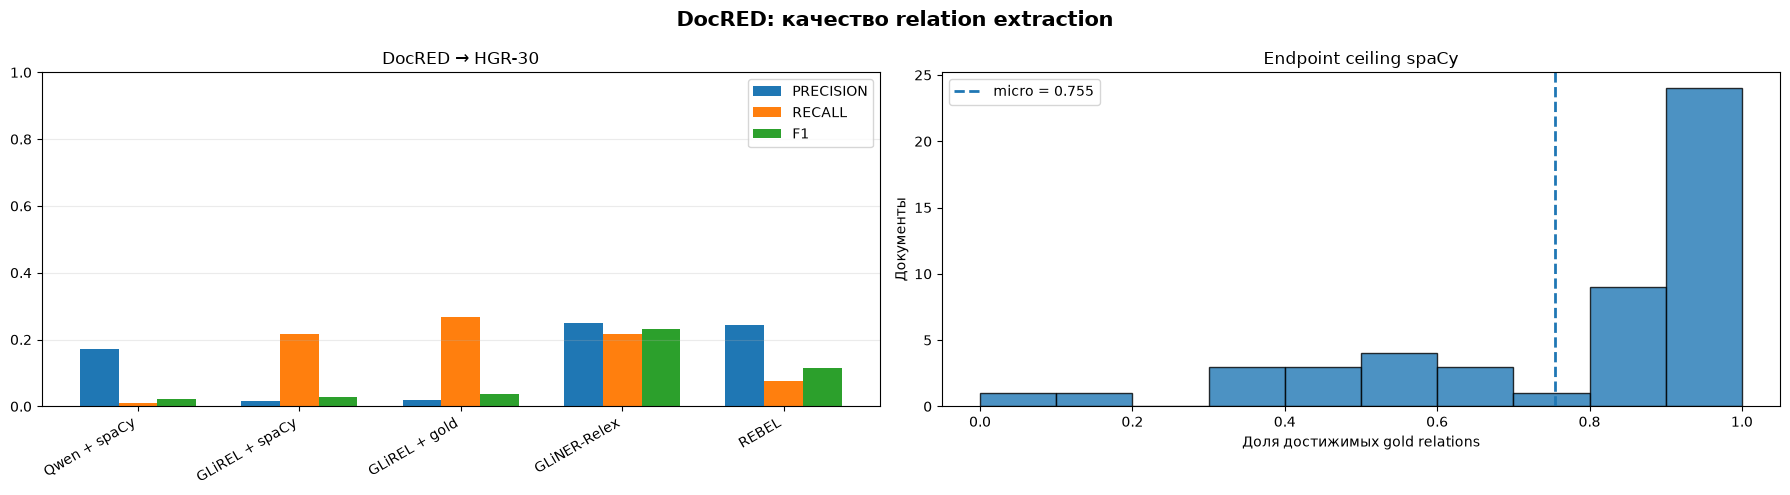

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# for ax, schema_mode, title in zip(
#     axes[:2], ["native", "hgr"], ["DocRED native schema", "DocRED → HGR-30"]
# ):
for ax, schema_mode, title in zip(
    axes[:1], ["hgr"], ["DocRED → HGR-30"]
):
    sub = docred_summary[docred_summary["schema"] == schema_mode]
    x = np.arange(len(sub))
    width = 0.24
    for offset, metric in zip([-width, 0, width], ["precision", "recall", "f1"]):
        ax.bar(x + offset, sub[metric], width, label=metric.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(sub["model"], rotation=30, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

axes[-1].hist(endpoint_df["endpoint_ceiling"].dropna(), bins=np.linspace(0, 1, 11), edgecolor="black", alpha=0.8)
axes[-1].axvline(overall_endpoint_ceiling, linestyle="--", linewidth=2, label=f"micro = {overall_endpoint_ceiling:.3f}")
axes[-1].set_title("Endpoint ceiling spaCy")
axes[-1].set_xlabel("Доля достижимых gold relations")
axes[-1].set_ylabel("Документы")
axes[-1].legend()

fig.suptitle("DocRED: качество relation extraction", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(PLOT_DIR / "docred_main_metrics.png", dpi=180, bbox_inches="tight")
plt.show()

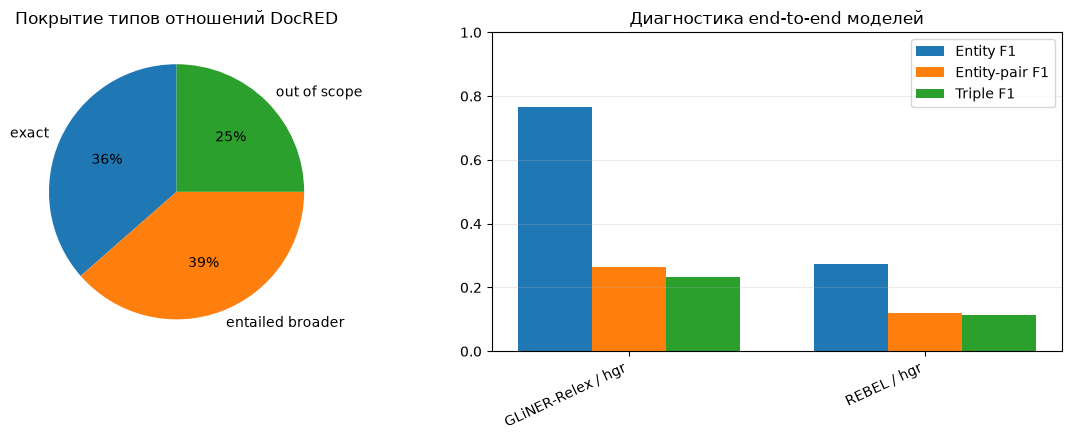

In [ ]:
mapping_stats = docred_mapping["statistics"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].pie(
    [mapping_stats["exact_relation_types"], mapping_stats["entailed_broader_relation_types"], mapping_stats["out_of_scope_relation_types"]],
    labels=["exact", "entailed broader", "out of scope"],
    autopct="%1.0f%%",
    startangle=90,
)
axes[0].set_title("Покрытие типов отношений DocRED")

end_to_end = docred_summary[docred_summary["model"].isin(["GLiNER-Relex", "REBEL"])]
x = np.arange(len(end_to_end))
width = 0.25
for offset, metric, label in zip([-width, 0, width], ["entity_f1", "pair_f1", "f1"], ["Entity F1", "Entity-pair F1", "Triple F1"]):
    axes[1].bar(x + offset, end_to_end[metric], width, label=label)
axes[1].set_xticks(x)
axes[1].set_xticklabels(end_to_end["model"] + " / " + end_to_end["schema"], rotation=25, ha="right")
axes[1].set_ylim(0, 1)
axes[1].set_title("Диагностика end-to-end моделей")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(PLOT_DIR / "docred_mapping_and_e2e.png", dpi=180, bbox_inches="tight")
plt.show()

# Часть II. Обнаружение галлюцинаций на RAGTruth и XSum

## 19. Единый набор целевых примеров

RAGTruth оценивается отдельно для `QA`, `Summary` и `Data2txt`. XSum образует четвёртую задачу. Агрегирование между задачами не выполняется в основной таблице, потому что плотность графов и природа источника заметно различаются.

In [ ]:
target_df = pd.concat([
    rt_pilot[["sample_id", "source_id", "task_type", "context", "query", "response", "hallucinated", "generator_model"]],
    (
        xsum_pilot[
            ["sample_id", "source_id", "task_type", "context", "query",
             "response", "hallucinated", "system"]
        ]
        .rename(columns={"system": "generator_model"})
    ),
], ignore_index=True)

print(target_df.groupby(["task_type", "hallucinated"]).size())


task_type  hallucinated
Data2txt   0               25
           1               25
QA         0               25
           1               25
Summary    0               25
           1               25
XSum       0               25
           1               25
dtype: int64


## 20. Извлечение графов Qwen + spaCy

In [ ]:
def run_target_llm_spacy():
    path = CACHE_DIR / f"target_llm_spacy_{PROCESSING_TAG}.jsonl"
    cached = load_cached_jsonl(path)
    if cached is not None:
        return cached

    from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
    quant = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16)
    tokenizer = AutoTokenizer.from_pretrained(LLM_MODEL)
    model = AutoModelForCausalLM.from_pretrained(
        LLM_MODEL, device_map="auto", quantization_config=quant, torch_dtype=torch.float16
    ).eval()

    results = []
    for row in tqdm(target_df.to_dict("records"), desc="Qwen / targets"):
        results.append({
            "sample_id": row["sample_id"],
            "model": "Qwen + spaCy",
            "context_graph": extract_document_llm_spacy(row["context"], hgr_schema, tokenizer, model),
            "query_graph": extract_document_llm_spacy(row["query"], hgr_schema, tokenizer, model) if row["query"].strip() else {"entities": [], "relations": []},
            "response_graph": extract_document_llm_spacy(row["response"], hgr_schema, tokenizer, model),
        })
    save_jsonl(results, path)
    release_model(model, tokenizer)
    return results

if RUN_MODELS["llm_spacy"]:
    target_llm = run_target_llm_spacy()

## 21. Извлечение графов GLiREL + spaCy

In [ ]:
def run_target_glirel_spacy():
    path = CACHE_DIR / f"target_glirel_spacy_{PROCESSING_TAG}.jsonl"
    cached = load_cached_jsonl(path)
    if cached is not None:
        return cached

    from glirel import GLiREL
    model = GLiREL.from_pretrained(GLIREL_MODEL)
    results = []
    for row in tqdm(target_df.to_dict("records"), desc="GLiREL / targets"):
        def run_one(text):
            ents = spacy_entities(text)
            return extract_document_glirel(text, hgr_schema, model, ents)
        results.append({
            "sample_id": row["sample_id"],
            "model": "GLiREL + spaCy",
            "context_graph": run_one(row["context"]),
            "query_graph": run_one(row["query"]) if row["query"].strip() else {"entities": [], "relations": []},
            "response_graph": run_one(row["response"]),
        })
    save_jsonl(results, path)
    release_model(model)
    return results

if RUN_MODELS["glirel_spacy"]:
    target_glirel = run_target_glirel_spacy()

## 22. Извлечение графов GLiNER-Relex

In [ ]:
def run_target_gliner_relex():
    path = CACHE_DIR / f"target_gliner_relex_{PROCESSING_TAG}.jsonl"
    cached = load_cached_jsonl(path)
    if cached is not None:
        return cached

    from gliner import GLiNER
    model = GLiNER.from_pretrained(GLINER_RELEX_MODEL)
    results = []
    for row in tqdm(target_df.to_dict("records"), desc="GLiNER-Relex / targets"):
        results.append({
            "sample_id": row["sample_id"],
            "model": "GLiNER-Relex",
            "context_graph": extract_document_gliner_relex(row["context"], hgr_schema, model),
            "query_graph": extract_document_gliner_relex(row["query"], hgr_schema, model) if row["query"].strip() else {"entities": [], "relations": []},
            "response_graph": extract_document_gliner_relex(row["response"], hgr_schema, model),
        })
    save_jsonl(results, path)
    release_model(model)
    return results

if RUN_MODELS["gliner_relex"]:
    target_gliner = run_target_gliner_relex()

GLiNER-Relex / targets: 100%|██████████| 200/200 [22:37<00:00,  6.79s/it] 


## 23. Извлечение графов REBEL

На целевых датасетах relation labels REBEL не принудительно переводятся в HGR-30. Контекст, запрос и ответ извлекаются одной и той же моделью, поэтому Relation Preservation сравнивает точные нормализованные native labels внутри REBEL-графов.

In [ ]:
def run_target_rebel():
    path = CACHE_DIR / f"target_rebel_{PROCESSING_TAG}.jsonl"
    cached = load_cached_jsonl(path)
    if cached is not None:
        return cached

    from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
    tokenizer = AutoTokenizer.from_pretrained(REBEL_MODEL)
    model = AutoModelForSeq2SeqLM.from_pretrained(REBEL_MODEL, device_map="auto").eval()
    results = []
    for row in tqdm(target_df.to_dict("records"), desc="REBEL / targets"):
        results.append({
            "sample_id": row["sample_id"],
            "model": "REBEL",
            "context_graph": extract_document_rebel(row["context"], tokenizer, model, "target_native"),
            "query_graph": extract_document_rebel(row["query"], tokenizer, model, "target_native") if row["query"].strip() else {"entities": [], "relations": []},
            "response_graph": extract_document_rebel(row["response"], tokenizer, model, "target_native"),
        })
    save_jsonl(results, path)
    release_model(model, tokenizer)
    return results

if RUN_MODELS["rebel"]:
    target_rebel = run_target_rebel()

## 24. EG, RP и subgraph connectivity

- **EG:** доля сущностей ответа, присутствующих в контексте или запросе;
- **RP:** доля направленных отношений ответа, поддержанных отношением с тем же relation ID и совпадающими endpoints;
- **SC:** число рёбер в крупнейшей слабосвязной компоненте поддержанного подграфа, делённое на число всех рёбер ответа.

> **Неочевидное решение:** пустые графы не удаляются и не получают идеальный score. Соответствующие метрики становятся `NaN`, а итоговый детектор получает отдельные missingness indicators.

In [ ]:
def union_graphs(*graphs: dict) -> dict:
    return deduplicate_graph({
        "entities": [e for g in graphs for e in g.get("entities", [])],
        "relations": [r for g in graphs for r in g.get("relations", [])],
    })


def relation_supported(response_rel: dict, reference_relations: list[dict]) -> bool:
    return any(
        response_rel["relation_id"] == ref["relation_id"]
        and entity_match(response_rel["head_text"], ref["head_text"])
        and entity_match(response_rel["tail_text"], ref["tail_text"])
        for ref in reference_relations
    )


def graph_alignment_metrics(context_graph: dict, query_graph: dict, response_graph: dict) -> dict:
    reference = union_graphs(context_graph, query_graph)
    response_entities = {normalize_entity(e["text"]) for e in response_graph.get("entities", []) if normalize_entity(e["text"])}
    reference_entities = {normalize_entity(e["text"]) for e in reference.get("entities", []) if normalize_entity(e["text"])}
    response_relations = response_graph.get("relations", [])

    eg = np.nan if not response_entities else len(response_entities & reference_entities) / len(response_entities)

    supported = [r for r in response_relations if relation_supported(r, reference.get("relations", []))]
    rp = np.nan if not response_relations else len(supported) / len(response_relations)

    if not response_relations:
        sc = np.nan
    elif not supported:
        sc = 0.0
    else:
        graph = nx.Graph()
        for rel in supported:
            graph.add_edge(normalize_entity(rel["head_text"]), normalize_entity(rel["tail_text"]))
        largest_nodes = max(nx.connected_components(graph), key=len)
        largest_edges = sum(1 for u, v in graph.edges() if u in largest_nodes and v in largest_nodes)
        sc = largest_edges / len(response_relations)

    return {
        "eg": eg,
        "rp": rp,
        "sc": sc,
        "missing_eg": int(np.isnan(eg)),
        "missing_rp": int(np.isnan(rp)),
        "missing_sc": int(np.isnan(sc)),
        "context_entity_empty": int(len(context_graph.get("entities", [])) == 0),
        "context_relation_empty": int(len(context_graph.get("relations", [])) == 0),
        "response_entity_empty": int(len(response_graph.get("entities", [])) == 0),
        "response_relation_empty": int(len(response_graph.get("relations", [])) == 0),
        "n_context_entities": len(context_graph.get("entities", [])),
        "n_context_relations": len(context_graph.get("relations", [])),
        "n_response_entities": len(response_graph.get("entities", [])),
        "n_response_relations": len(response_graph.get("relations", [])),
    }

In [ ]:
# target_graph_outputs = target_llm + target_glirel + target_gliner + target_rebel
target_graph_outputs = target_gliner
meta_by_id = target_df.set_index("sample_id").to_dict("index")

alignment_rows = []
for item in target_graph_outputs:
    meta = meta_by_id[item["sample_id"]]
    metrics = graph_alignment_metrics(item["context_graph"], item["query_graph"], item["response_graph"])
    alignment_rows.append({
        "sample_id": item["sample_id"],
        "source_id": meta["source_id"],
        "task_type": meta["task_type"],
        "hallucinated": int(meta["hallucinated"]),
        "model": item["model"],
        **metrics,
    })

alignment_df = pd.DataFrame(alignment_rows)
alignment_df.to_csv(OUT_DIR / "target_alignment_scores.csv", index=False)
display(alignment_df.groupby(["task_type", "model"])[["eg", "rp", "sc", "response_entity_empty", "response_relation_empty"]].mean().round(3))

,,eg,rp,sc,response_entity_empty,response_relation_empty
task_type,model,,,,,
Data2txt,GLiNER-Relex,0.233,0.293,0.293,0.0,0.00
QA,GLiNER-Relex,0.459,0.134,0.111,0.0,0.50
Summary,GLiNER-Relex,0.407,0.235,0.222,0.0,0.06
XSum,GLiNER-Relex,0.155,0.089,0.089,0.0,0.46


## 25. Линейный детектор с неотрицательными весами

Входные признаки — риски `1−EG`, `1−RP`, `1−SC` и три индикатора отсутствующих метрик. Коэффициенты рисков ограничены снизу нулём: ухудшение графового согласования не должно математически уменьшать вероятность галлюцинации.

Оценка выполняется nested cross-validation с группировкой по `source_id`. Итоговые accuracy, precision, recall, F1 и ROC-AUC считаются по out-of-fold предсказаниям.

In [ ]:
FEATURES = ["risk_eg", "risk_rp", "risk_sc", "missing_eg", "missing_rp", "missing_sc"]


def prepare_features(df: pd.DataFrame, medians: Optional[dict] = None) -> tuple[np.ndarray, dict]:
    work = df.copy()
    work["risk_eg"] = 1.0 - work["eg"]
    work["risk_rp"] = 1.0 - work["rp"]
    work["risk_sc"] = 1.0 - work["sc"]
    if medians is None:
        medians = {c: float(work[c].median()) if work[c].notna().any() else 0.5 for c in ["risk_eg", "risk_rp", "risk_sc"]}
    for c in ["risk_eg", "risk_rp", "risk_sc"]:
        work[c] = work[c].fillna(medians[c])
    return work[FEATURES].to_numpy(dtype=float), medians


def sigmoid(z):
    z = np.clip(z, -30, 30)
    return 1.0 / (1.0 + np.exp(-z))


def fit_constrained_logit(X: np.ndarray, y: np.ndarray, l2: float = 1.0) -> np.ndarray:
    def objective(theta):
        logits = theta[0] + X @ theta[1:]
        p = np.clip(sigmoid(logits), 1e-8, 1 - 1e-8)
        nll = -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()
        return nll + l2 * np.square(theta[1:]).sum() / max(len(y), 1)

    init = np.zeros(X.shape[1] + 1)
    bounds = [(None, None)] + [(0.0, None)] * X.shape[1]
    result = minimize(objective, init, method="L-BFGS-B", bounds=bounds)
    if not result.success:
        raise RuntimeError(result.message)
    return result.x


def choose_f1_threshold(y_true: np.ndarray, probs: np.ndarray) -> float:
    candidates = np.unique(np.r_[0.0, probs, 1.0])
    scores = [f1_score(y_true, probs >= t, zero_division=0) for t in candidates]
    return float(candidates[int(np.argmax(scores))])


def grouped_splitter(y: np.ndarray, groups: np.ndarray, n_splits: int, seed: int):
    try:
        return list(StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(np.zeros(len(y)), y, groups))
    except ValueError:
        return list(StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(np.zeros(len(y)), y))

In [ ]:
def nested_oof_detector(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    y = df["hallucinated"].to_numpy(dtype=int)
    groups = df["source_id"].astype(str).to_numpy()
    outer = grouped_splitter(y, groups, n_splits=5, seed=RANDOM_SEED)
    l2_grid = [0.01, 0.1, 1.0, 10.0]

    oof_prob = np.zeros(len(df), dtype=float)
    oof_pred = np.zeros(len(df), dtype=int)
    fold_rows = []

    for fold, (train_idx, test_idx) in enumerate(outer):
        train_df = df.iloc[train_idx]
        test_df = df.iloc[test_idx]
        y_train = y[train_idx]
        train_groups = groups[train_idx]
        inner = grouped_splitter(y_train, train_groups, n_splits=3, seed=RANDOM_SEED + fold)

        best_l2, best_loss, best_inner_prob = None, np.inf, None
        for l2 in l2_grid:
            inner_prob = np.zeros(len(train_idx), dtype=float)
            for inner_train, inner_val in inner:
                inner_train_df = train_df.iloc[inner_train]
                inner_val_df = train_df.iloc[inner_val]
                X_tr, med = prepare_features(inner_train_df)
                X_val, _ = prepare_features(inner_val_df, med)
                theta = fit_constrained_logit(X_tr, y_train[inner_train], l2)
                inner_prob[inner_val] = sigmoid(theta[0] + X_val @ theta[1:])
            p = np.clip(inner_prob, 1e-8, 1 - 1e-8)
            loss = -(y_train * np.log(p) + (1 - y_train) * np.log(1 - p)).mean()
            if loss < best_loss:
                best_l2, best_loss, best_inner_prob = l2, loss, inner_prob.copy()

        threshold = choose_f1_threshold(y_train, best_inner_prob)
        X_train, medians = prepare_features(train_df)
        X_test, _ = prepare_features(test_df, medians)
        theta = fit_constrained_logit(X_train, y_train, best_l2)
        probs = sigmoid(theta[0] + X_test @ theta[1:])
        oof_prob[test_idx] = probs
        oof_pred[test_idx] = (probs >= threshold).astype(int)
        fold_rows.append({
            "fold": fold,
            "l2": best_l2,
            "threshold": threshold,
            "intercept": theta[0],
            **{f"coef_{name}": value for name, value in zip(FEATURES, theta[1:])},
        })

    result = df[["sample_id", "source_id", "task_type", "model", "hallucinated"]].copy()
    result["probability"] = oof_prob
    result["prediction"] = oof_pred
    metrics = {
        "accuracy": accuracy_score(y, oof_pred),
        "precision": precision_score(y, oof_pred, zero_division=0),
        "recall": recall_score(y, oof_pred, zero_division=0),
        "f1": f1_score(y, oof_pred, zero_division=0),
        "roc_auc": roc_auc_score(y, oof_prob),
        "n": len(y),
        "folds": fold_rows,
    }
    return result, metrics

In [ ]:
hallucination_summaries = []
hallucination_predictions = []
coefficient_rows = []

for (task, model_name), sub in alignment_df.groupby(["task_type", "model"], sort=True):
    pred_df, metrics = nested_oof_detector(sub.reset_index(drop=True))
    hallucination_predictions.append(pred_df)
    hallucination_summaries.append({
        "task_type": task,
        "model": model_name,
        **{k: v for k, v in metrics.items() if k != "folds"},
    })
    for fold in metrics["folds"]:
        coefficient_rows.append({"task_type": task, "model": model_name, **fold})

hallucination_summary = pd.DataFrame(hallucination_summaries)
hallucination_oof = pd.concat(hallucination_predictions, ignore_index=True)
coefficients_df = pd.DataFrame(coefficient_rows)

hallucination_summary.to_csv(OUT_DIR / "hallucination_metrics.csv", index=False)
hallucination_oof.to_csv(OUT_DIR / "hallucination_oof_predictions.csv", index=False)
coefficients_df.to_csv(OUT_DIR / "hallucination_detector_coefficients.csv", index=False)
display(hallucination_summary.round(3))

,task_type,model,accuracy,precision,recall,f1,roc_auc,n
0,Data2txt,GLiNER-Relex,0.54,0.525,0.84,0.646,0.616,50
1,QA,GLiNER-Relex,0.50,0.500,1.00,0.667,0.417,50
2,Summary,GLiNER-Relex,0.50,0.500,0.96,0.658,0.452,50
3,XSum,GLiNER-Relex,0.50,0.500,1.00,0.667,0.478,50


## 26. Графики обнаружения галлюцинаций

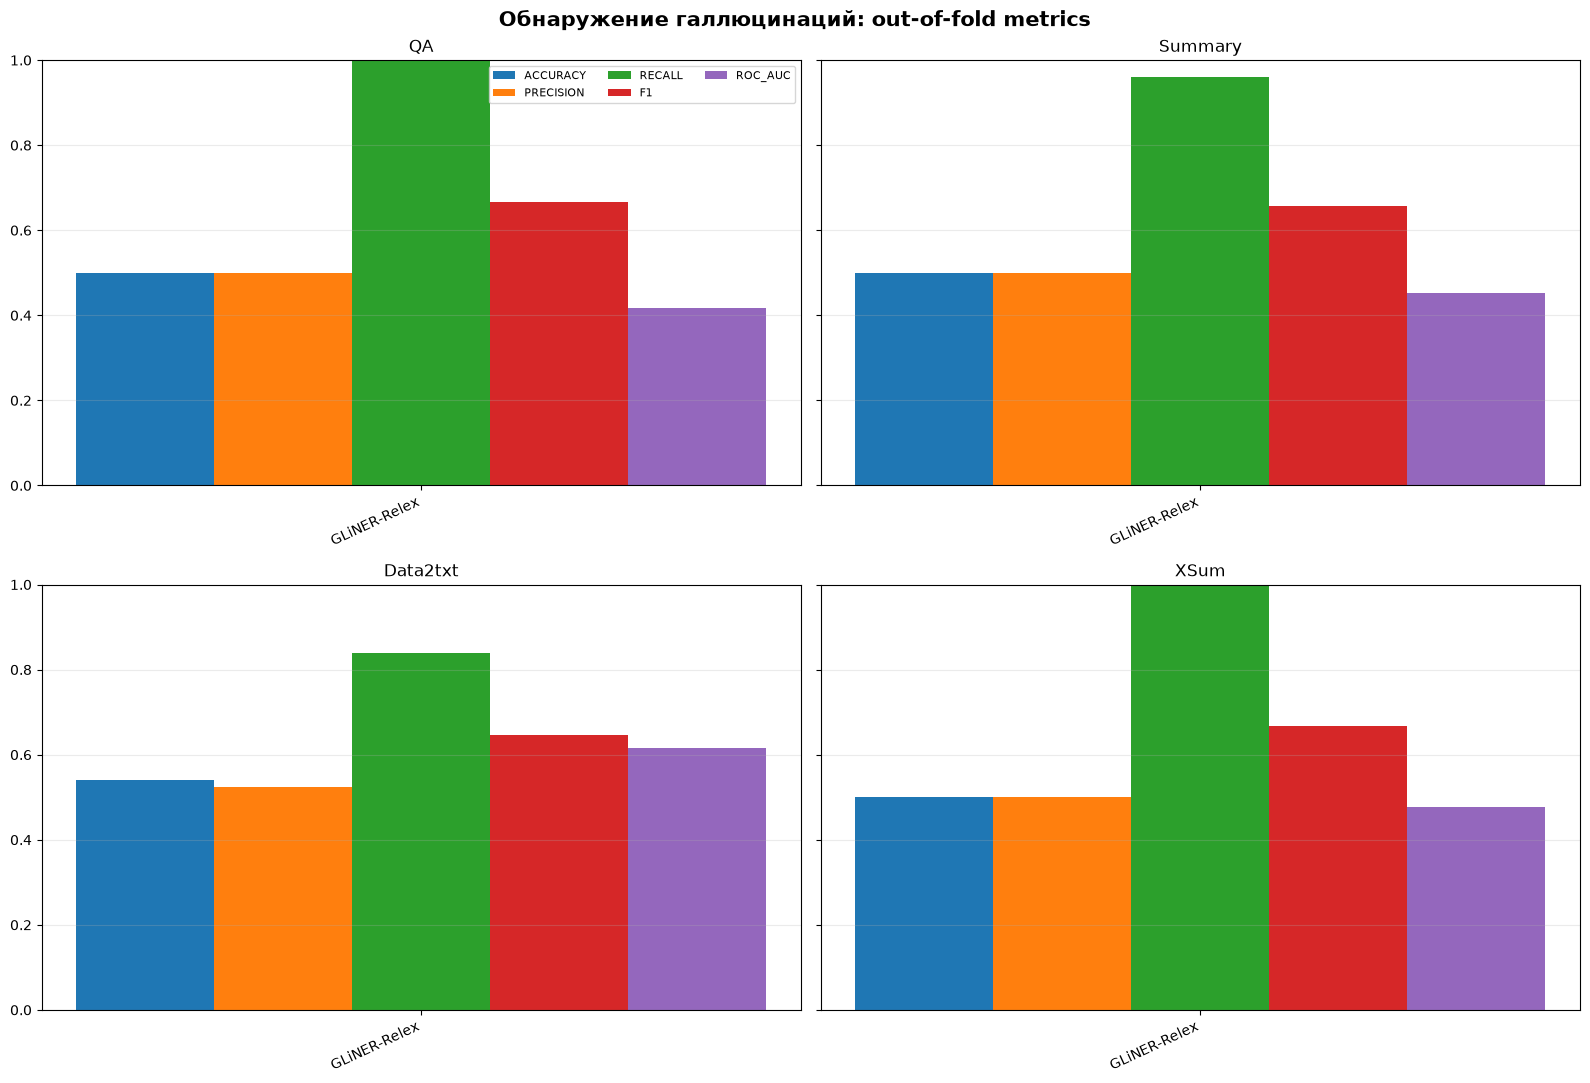

In [ ]:
metrics_order = ["accuracy", "precision", "recall", "f1", "roc_auc"]
tasks = ["QA", "Summary", "Data2txt", "XSum"]
# models = ["Qwen + spaCy", "GLiREL + spaCy", "GLiNER-Relex", "REBEL"]
models = ["GLiNER-Relex"]

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=True)
for ax, task in zip(axes.flat, tasks):
    sub = hallucination_summary[hallucination_summary["task_type"] == task].set_index("model").reindex(models)
    x = np.arange(len(models))
    width = 0.15
    for i, metric in enumerate(metrics_order):
        ax.bar(x + (i - 2) * width, sub[metric], width, label=metric.upper())
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(task)
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].legend(ncol=3, fontsize=8)
fig.suptitle("Обнаружение галлюцинаций: out-of-fold metrics", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(PLOT_DIR / "hallucination_metrics_by_task.png", dpi=180, bbox_inches="tight")
plt.show()

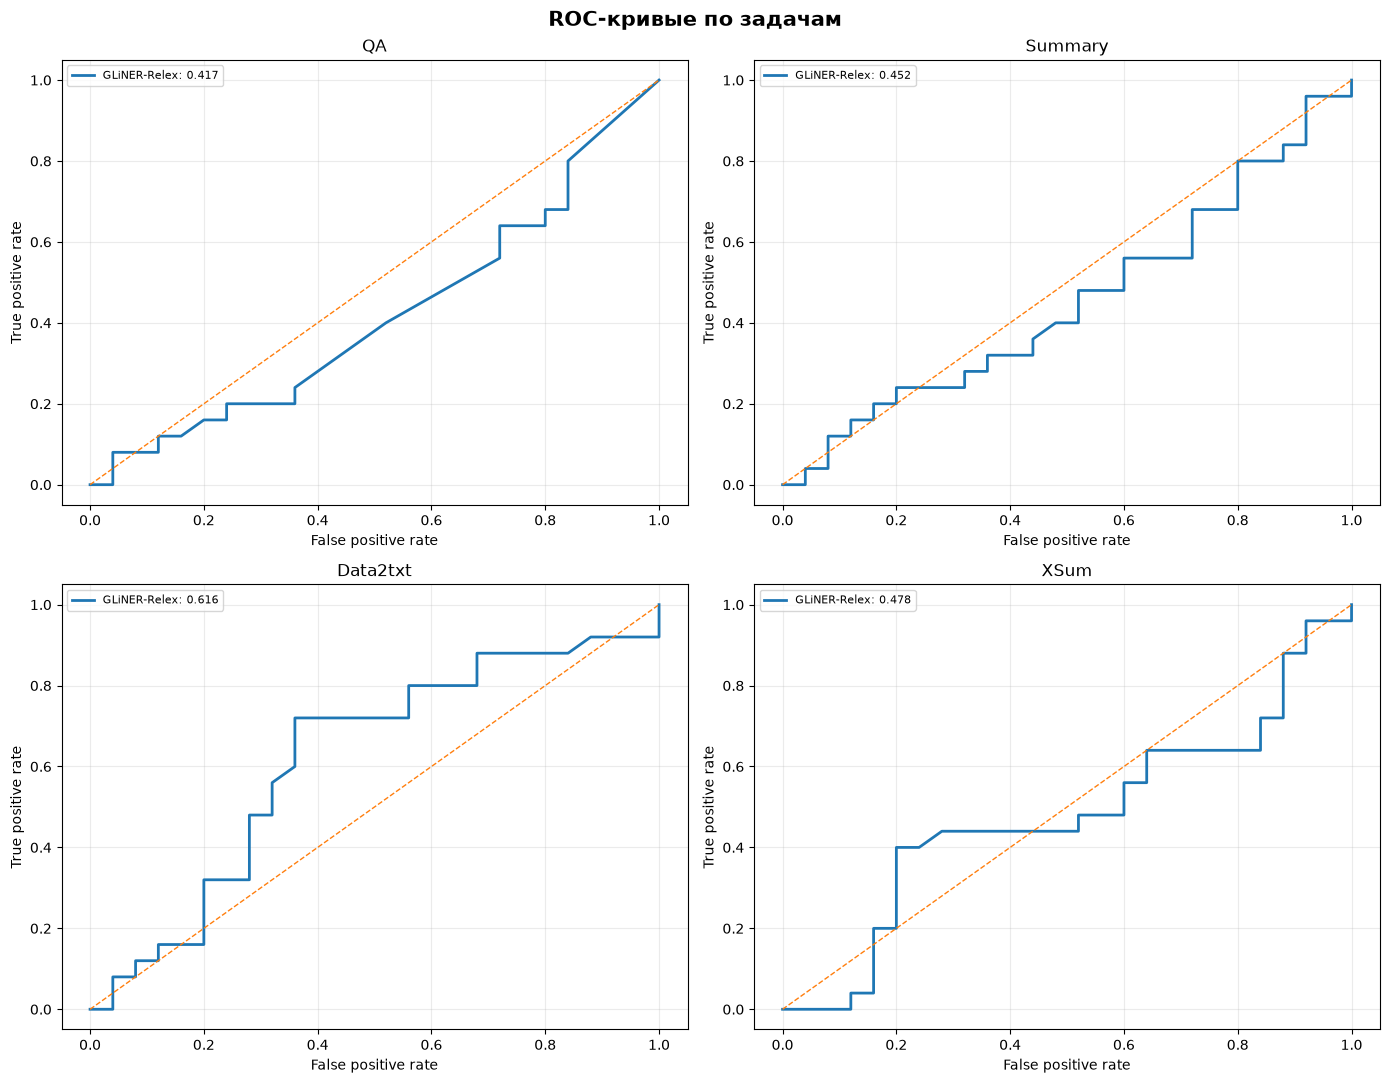

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, task in zip(axes.flat, tasks):
    for model_name in models:
        sub = hallucination_oof[
            (hallucination_oof["task_type"] == task) &
            (hallucination_oof["model"] == model_name)
        ]
        fpr, tpr, _ = roc_curve(sub["hallucinated"], sub["probability"])
        score = roc_auc_score(sub["hallucinated"], sub["probability"])
        ax.plot(fpr, tpr, linewidth=2, label=f"{model_name}: {score:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    ax.set_title(task)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)
fig.suptitle("ROC-кривые по задачам", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(PLOT_DIR / "roc_curves.png", dpi=180, bbox_inches="tight")
plt.show()

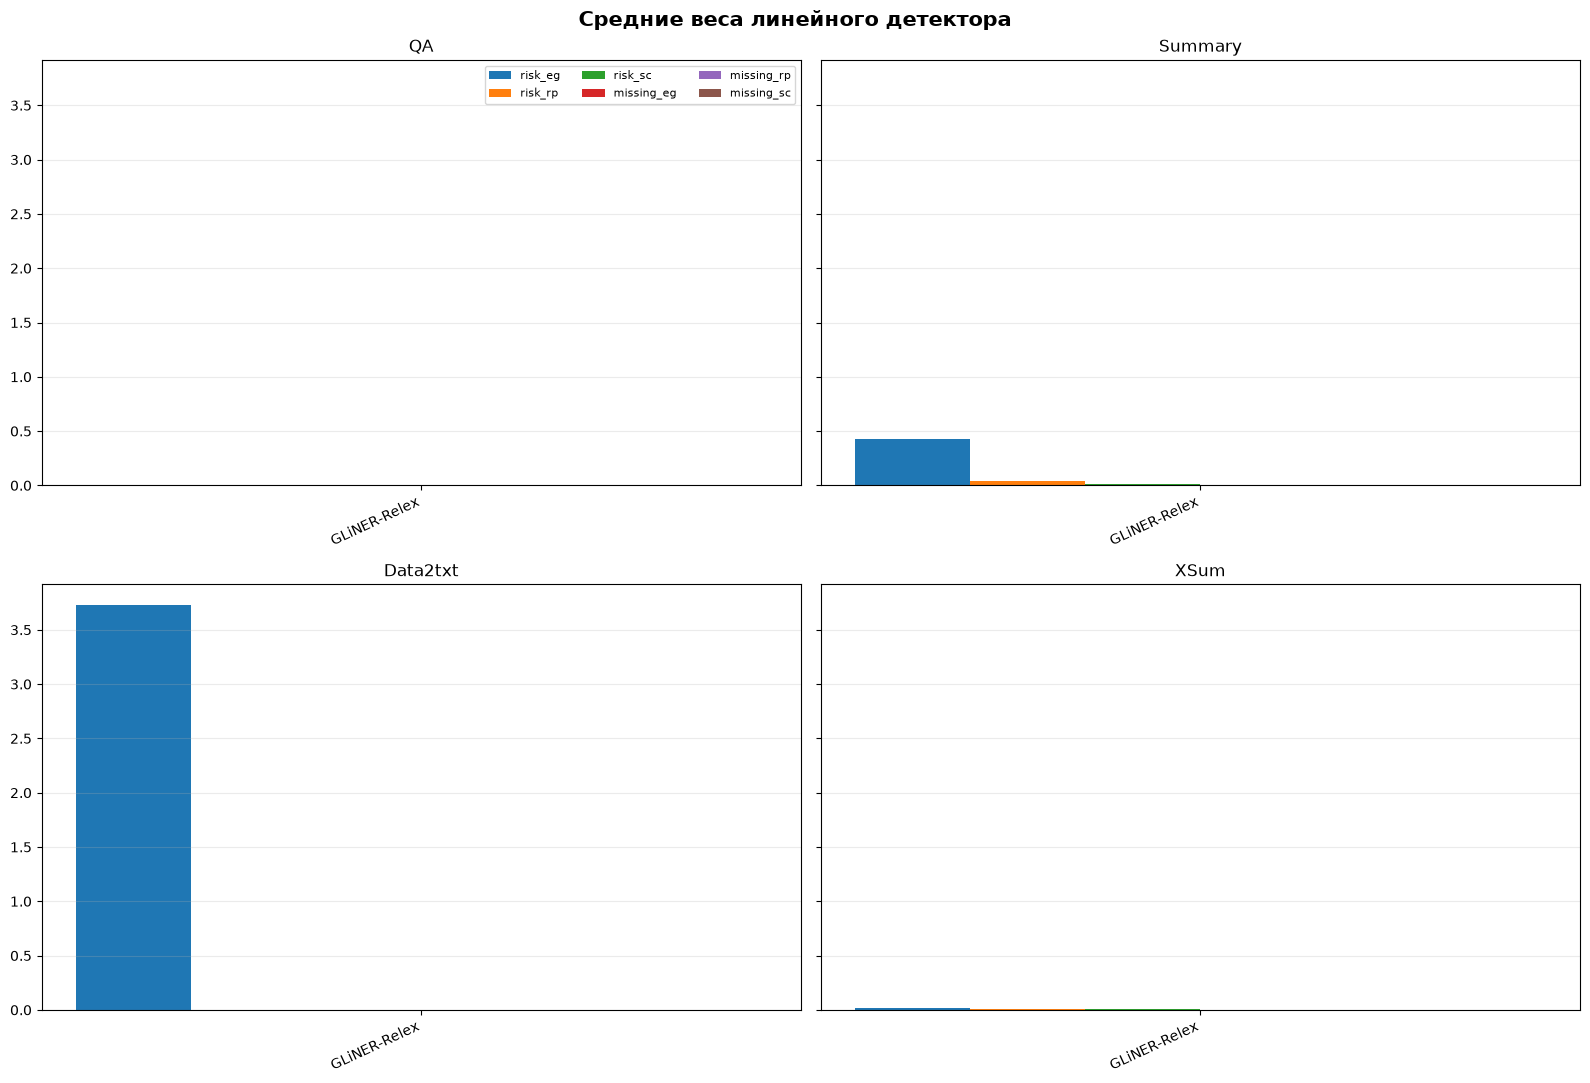

In [ ]:
# Средние коэффициенты по внешним folds: показывает, какие компоненты реально использует детектор.
coef_cols = [f"coef_{x}" for x in FEATURES]
coef_mean = coefficients_df.groupby(["task_type", "model"])[coef_cols].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=True)
for ax, task in zip(axes.flat, tasks):
    sub = coef_mean[coef_mean["task_type"] == task].set_index("model").reindex(models)
    x = np.arange(len(models))
    width = 0.12
    for i, col in enumerate(coef_cols):
        ax.bar(x + (i - 2.5) * width, sub[col], width, label=col.replace("coef_", ""))
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right")
    ax.set_title(task)
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].legend(ncol=3, fontsize=8)
fig.suptitle("Средние веса линейного детектора", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(PLOT_DIR / "detector_coefficients.png", dpi=180, bbox_inches="tight")
plt.show()

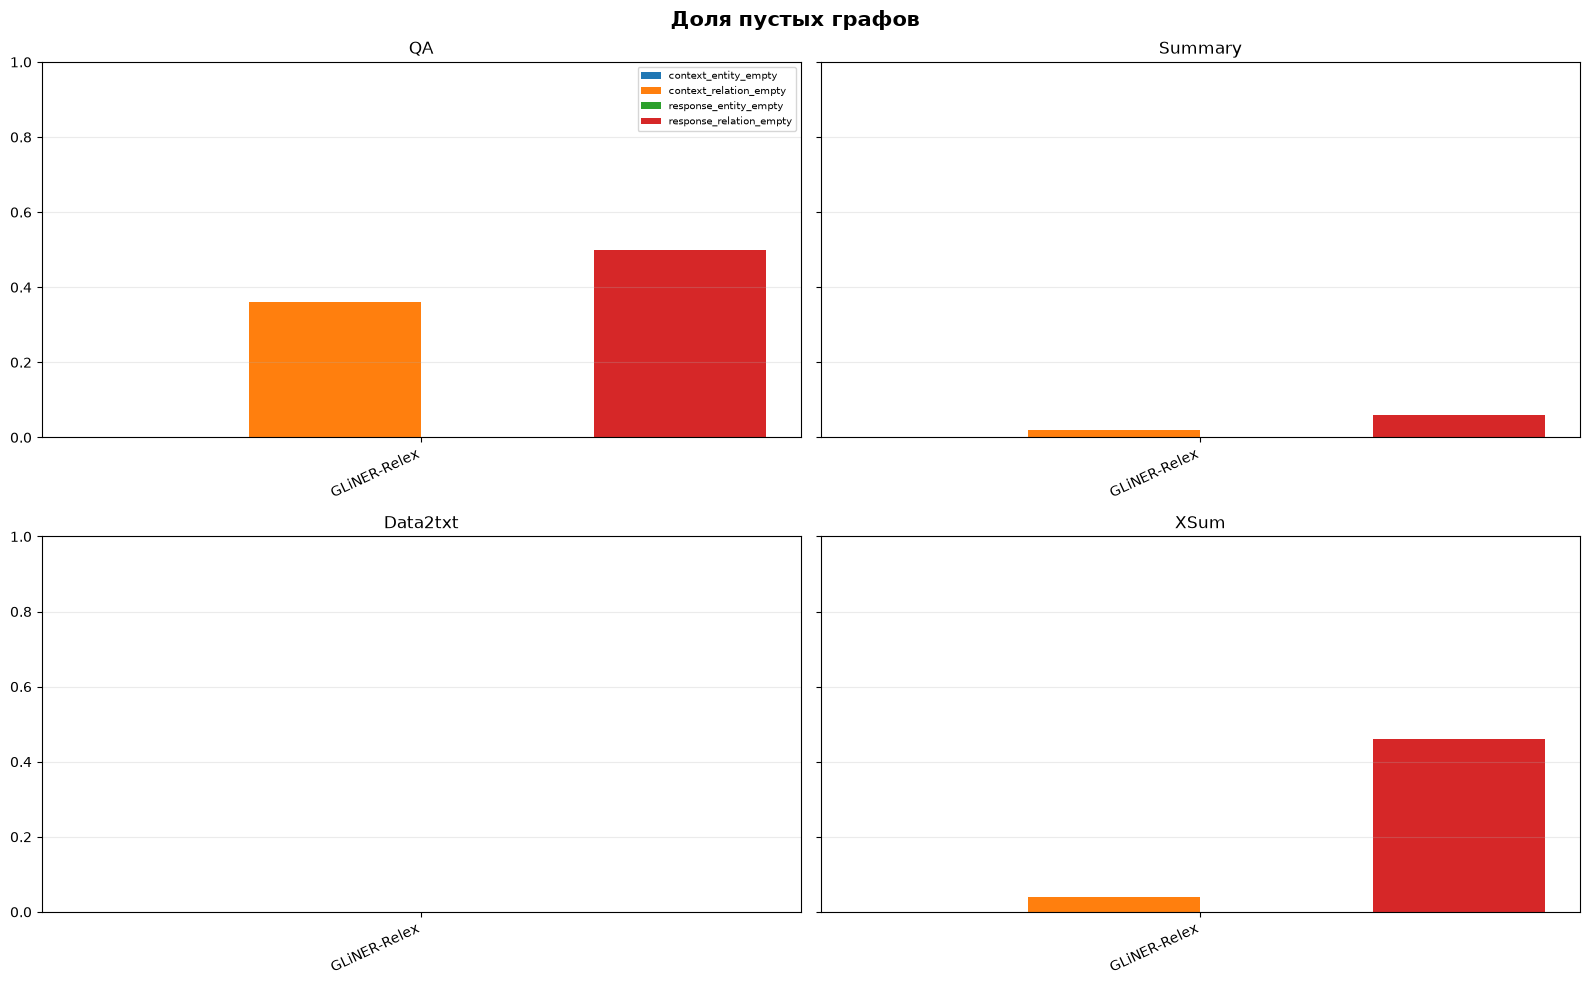

In [ ]:
empty_stats = alignment_df.groupby(["task_type", "model"])[
    ["context_entity_empty", "context_relation_empty", "response_entity_empty", "response_relation_empty"]
].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)
for ax, task in zip(axes.flat, tasks):
    sub = empty_stats[empty_stats["task_type"] == task].set_index("model").reindex(models)
    x = np.arange(len(models))
    width = 0.2
    for i, metric in enumerate(["context_entity_empty", "context_relation_empty", "response_entity_empty", "response_relation_empty"]):
        ax.bar(x + (i - 1.5) * width, sub[metric], width, label=metric)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=25, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(task)
    ax.grid(axis="y", alpha=0.25)
axes[0, 0].legend(fontsize=7)
fig.suptitle("Доля пустых графов", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(PLOT_DIR / "empty_graph_rates.png", dpi=180, bbox_inches="tight")
plt.show()

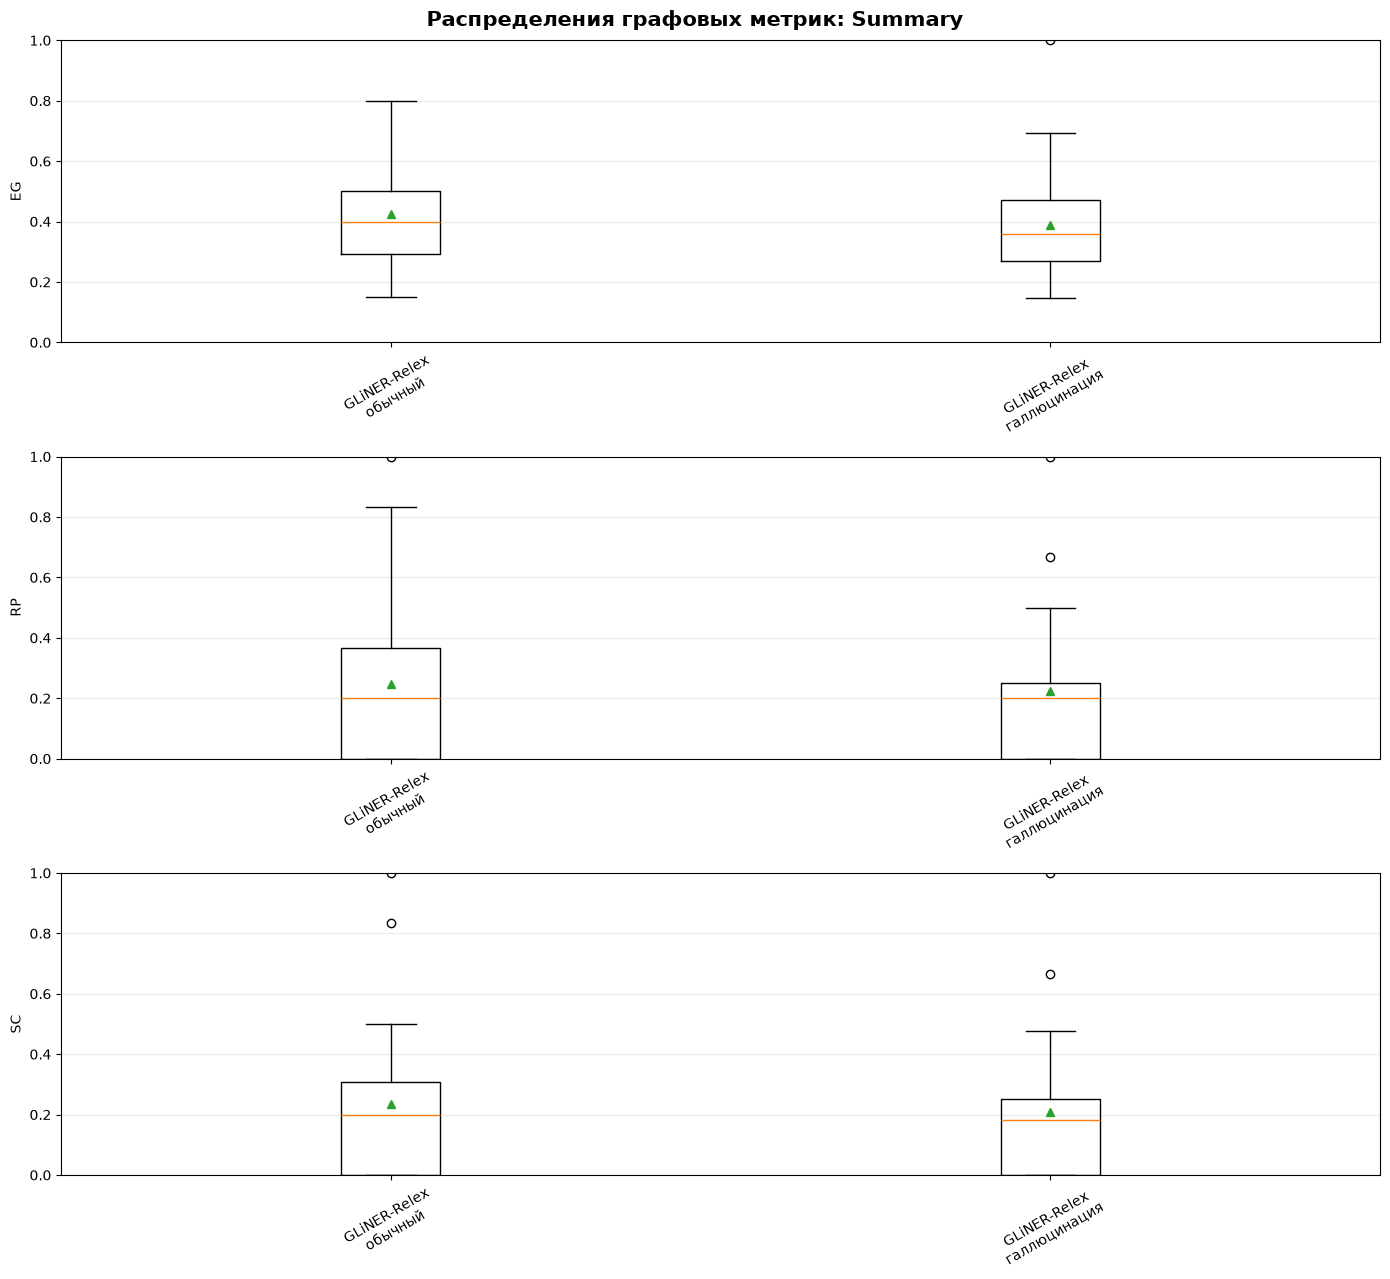

In [ ]:
# Распределения EG/RP/SC для одной выбранной задачи; значение легко изменить.
TASK_FOR_DISTRIBUTION = "Summary"
sub = alignment_df[alignment_df["task_type"] == TASK_FOR_DISTRIBUTION]
fig, axes = plt.subplots(3, 1, figsize=(14, 13))
for ax, metric in zip(axes, ["eg", "rp", "sc"]):
    data, labels = [], []
    for model_name in models:
        for label, label_name in [(0, "обычный"), (1, "галлюцинация")]:
            values = sub[(sub["model"] == model_name) & (sub["hallucinated"] == label)][metric].dropna()
            data.append(values)
            labels.append(f"{model_name}\n{label_name}")
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_ylim(0, 1)
    ax.set_ylabel(metric.upper())
    ax.grid(axis="y", alpha=0.25)
    ax.tick_params(axis="x", rotation=30)
fig.suptitle(f"Распределения графовых метрик: {TASK_FOR_DISTRIBUTION}", fontsize=15, fontweight="bold")
fig.tight_layout()
fig.savefig(PLOT_DIR / f"score_distributions_{TASK_FOR_DISTRIBUTION.lower()}.png", dpi=180, bbox_inches="tight")
plt.show()

## 27. Итоговая сводка и сохранение результатов

Файлы `cache/*.jsonl` содержат сырые графы и позволяют менять EG/RP/SC или классификатор без повторного запуска моделей.

In [ ]:
report = {
    "random_seed": RANDOM_SEED,
    "processing": {
        "use_windowing": USE_WINDOWING,
        "mode": PROCESSING_TAG,
        "single_pass_truncate_to_context": SINGLE_PASS_TRUNCATE_TO_CONTEXT,
        "window_overlap_ratio": WINDOW_OVERLAP_RATIO,
        "window_min_overlap_sentences": WINDOW_MIN_OVERLAP_SENTENCES,
    },
    "sample_sizes": {
        "DocRED": N_DOCRED,
        "RAGTruth_QA": N_PER_TARGET_TASK,
        "RAGTruth_Summary": N_PER_TARGET_TASK,
        "RAGTruth_Data2txt": N_PER_TARGET_TASK,
        "XSum": N_PER_TARGET_TASK,
    },
    "models": {
        "spacy": SPACY_MODEL,
        "llm": LLM_MODEL,
        "glirel": GLIREL_MODEL,
        "gliner_relex": GLINER_RELEX_MODEL,
        "rebel": REBEL_MODEL,
    },
    "ontology": {
        "id": ontology["ontology_id"],
        "version": ontology["version"],
        "sha256": sha256_file(ONTOLOGY_PATH),
    },
    "docred_mapping": {
        "id": docred_mapping["mapping_id"],
        "version": docred_mapping["version"],
        "sha256": sha256_file(DOCRED_MAPPING_PATH),
        "statistics": docred_mapping["statistics"],
    },
    "endpoint_ceiling": overall_endpoint_ceiling,
    "docred_metrics": docred_summary.to_dict("records"),
    "hallucination_metrics": hallucination_summary.to_dict("records"),
}

(OUT_DIR / f"full_report_{PROCESSING_TAG}.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8"
)

print("Сохранено:")
for path in sorted(OUT_DIR.glob("*")):
    print(" -", path)

Сохранено:
 - /mnt/hdd2/29i_kos/notebook/results/cache
 - /mnt/hdd2/29i_kos/notebook/results/docred_endpoint_ceiling.csv
 - /mnt/hdd2/29i_kos/notebook/results/docred_per_document.csv
 - /mnt/hdd2/29i_kos/notebook/results/docred_summary.csv
 - /mnt/hdd2/29i_kos/notebook/results/full_report_single_pass.json
 - /mnt/hdd2/29i_kos/notebook/results/hallucination_detector_coefficients.csv
 - /mnt/hdd2/29i_kos/notebook/results/hallucination_metrics.csv
 - /mnt/hdd2/29i_kos/notebook/results/hallucination_oof_predictions.csv
 - /mnt/hdd2/29i_kos/notebook/results/plots
 - /mnt/hdd2/29i_kos/notebook/results/sample_manifest.json
 - /mnt/hdd2/29i_kos/notebook/results/target_alignment_scores.csv
